# Khai báo dữ liệu

In [168]:
%pip install openpyxl -q
import os, sys
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib
from scipy import stats
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
import warnings

path_to_file= r"vietnam_housing_dataset.csv"
vietnam_housing = pd.read_csv(
    r"vietnam_housing_dataset.csv",
    sep=";",
    engine="python")
vietnam_housing.drop(columns=['Address'], inplace=True)

Note: you may need to restart the kernel to use updated packages.


In [169]:
from sklearn.model_selection import train_test_split
seed = 42
index_all = np.arange(vietnam_housing.shape[0])
index_train, index_test = train_test_split(index_all, test_size=0.33, random_state=seed)

In [170]:
vietnam_housing_train = vietnam_housing.iloc[index_train]
vietnam_housing_test  = vietnam_housing.iloc[index_test]
print(f"train: {len(vietnam_housing_train)} / test: {len(vietnam_housing_test)} - Tỷ lệ: {len(vietnam_housing_train) / len(vietnam_housing):.3f}, {len(vietnam_housing_test) / len(vietnam_housing):.3f}")

train: 1772 / test: 874 - Tỷ lệ: 0.670, 0.330


In [171]:

# Lưu dữ liệu sau khi chia
import os
from pathlib import Path
# define experiment directory (change if you prefer another path)
exps_dir = Path("./exps")
(exps_dir / "data").mkdir(parents=True, exist_ok=True)
vietnam_housing_train.to_excel(f'{exps_dir}/data/train.xlsx', index=None)
vietnam_housing_test.to_excel(f'{exps_dir}/data/test.xlsx', index=None)
np.savez(f'{exps_dir}/data/idx.npz', id_train = index_train, id_test = index_test)


In [172]:
pd.read_excel(f'{exps_dir}/data/train.xlsx')

,Province,District,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,Hồ Chí Minh,Nhà Bè,22.4,4.0,3.0,Đông,Đông,1,2,2,Have certificate,Full,1.30
1,Hà Nội,Hà Đông,34.0,3.5,3.0,Tây - Bắc,Tây - Bắc,3,3,3,Have certificate,Basic,1.99
2,Hà Nội,Nam Từ Liêm,35.0,3.5,4.0,Đông - Bắc,Đông - Bắc,5,3,4,Have certificate,Full,5.50
3,Hải Phòng,Hồng Bàng,72.0,6.0,2.0,Tây,Tây,3,3,4,Have certificate,Full,4.20
4,Hồ Chí Minh,Gò Vấp,64.0,5.0,5.0,Đông - Nam,Đông - Nam,3,3,4,Have certificate,Full,7.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1767,Hồ Chí Minh,Quận 12,48.0,3.0,3.0,Tây - Nam,Tây - Nam,2,2,2,Have certificate,Full,3.30
1768,Hồ Chí Minh,Quận 12,30.0,3.0,4.5,Đông - Bắc,Đông - Nam,3,4,3,Have certificate,Basic,2.48
1769,Tiền Giang,Mỹ Tho,100.0,4.5,4.0,Bắc,Bắc,2,3,2,Have certificate,Full,2.68
1770,Hồ Chí Minh,Quận 8,79.2,10.0,10.0,Đông - Bắc,Đông - Bắc,2,1,1,Sale contract,Basic,4.40


## Tiền xử lý dữ liệu

In [173]:
# create explicit copies of the splits
vietnam_housing_train = vietnam_housing.iloc[index_train].copy()
vietnam_housing_test  = vietnam_housing.iloc[index_test].copy()
print(f"train: {len(vietnam_housing_train)} / test: {len(vietnam_housing_test)} - Tỷ lệ: {len(vietnam_housing_train) / len(vietnam_housing):.3f}, {len(vietnam_housing_test) / len(vietnam_housing):.3f}")

train: 1772 / test: 874 - Tỷ lệ: 0.670, 0.330


In [174]:
vietnam_housing_train.isna().any()


Province             False
District             False
Area                 False
Frontage             False
Access Road          False
House direction      False
Balcony direction    False
Floors               False
Bedrooms             False
Bathrooms            False
Legal status         False
Furniture state      False
Price                False
dtype: bool

In [175]:
vietnam_housing_test.isna().any()

Province             False
District             False
Area                 False
Frontage             False
Access Road          False
House direction      False
Balcony direction    False
Floors               False
Bedrooms             False
Bathrooms            False
Legal status         False
Furniture state      False
Price                False
dtype: bool

In [176]:
# Safe NA fill: tìm biến với khoảng trắng hoặc gạch dưới trước khi fillna
vietnam_housing_train = vietnam_housing_train.copy()

def colname(df, name):
    for cand in (name, name.replace(' ', '_'), name.lower().replace(' ', '_')):
        if cand in df.columns:
            return cand
    return None

for src in ['Frontage','Access Road','Floors','Bedrooms','Bathrooms','Area','Price']:
    c = colname(vietnam_housing_train, src)
    if c:
        vietnam_housing_train[c] = vietnam_housing_train[c].fillna(vietnam_housing_train[c].median())
    else:
        print(f"Warning: numeric column not found: {src}")

for src in ['House direction','Balcony direction','Legal status','Furniture state','Address']:
    c = colname(vietnam_housing_train, src)
    if c:
        vietnam_housing_train[c] = vietnam_housing_train[c].fillna('Unknown')
    else:
        print(f"Warning: categorical column not found: {src}")
# ...existing code...
# vietnam_housing_test

vietnam_housing_test = vietnam_housing_test.copy()

def colname(df, name):
    for cand in (name, name.replace(' ', '_'), name.lower().replace(' ', '_')):
        if cand in df.columns:
            return cand
    return None

for src in ['Frontage','Access Road','Floors','Bedrooms','Bathrooms','Area','Price']:
    c = colname(vietnam_housing_test, src)
    if c:
        vietnam_housing_test[c] = vietnam_housing_test[c].fillna(vietnam_housing_test[c].median())
    else:
        print(f"Warning: numeric column not found: {src}")

for src in ['House direction','Balcony direction','Legal status','Furniture state','Address']:
    c = colname(vietnam_housing_test, src)
    if c:
        vietnam_housing_test[c] = vietnam_housing_test[c].fillna('Unknown')
    else:
        print(f"Warning: categorical column not found: {src}")
# ...existing code...

In [177]:
vietnam_housing_train.describe()

,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,Price
count,1772.000000,1772.000000,1772.000000,1772.000000,1772.000000,1772.000000,1772.000000
mean,69.850113,5.451371,7.454938,3.218962,3.457111,3.353273,5.426270
std,50.980397,4.936180,7.009311,1.296532,1.217170,1.361496,2.229634
min,3.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,40.000000,4.000000,3.000000,2.000000,3.000000,2.000000,3.700000
50%,60.000000,4.500000,5.000000,3.000000,3.000000,3.000000,5.200000
75%,80.842500,5.000000,8.000000,4.000000,4.000000,4.000000,7.100000
max,494.000000,73.000000,60.000000,7.000000,9.000000,9.000000,10.900000


In [178]:
vietnam_housing_test.describe()

,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,Price
count,874.000000,874.000000,874.000000,874.000000,874.000000,874.000000,874.000000
mean,72.449519,5.537815,7.904405,3.191076,3.505721,3.358124,5.478707
std,49.045731,4.879929,8.592562,1.239430,1.108372,1.298915,2.265874
min,14.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.200000
25%,42.000000,4.000000,3.200000,2.000000,3.000000,2.000000,3.612500
50%,61.000000,4.500000,5.000000,3.000000,3.000000,3.000000,5.400000
75%,86.000000,5.000000,9.000000,4.000000,4.000000,4.000000,7.200000
max,501.000000,65.000000,85.000000,7.000000,9.000000,9.000000,10.000000


## Chuẩn hóa dữ liệu

# Vietnam_housing_train

In [179]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Sao chép dữ liệu để không làm thay đổi bản gốc
vietnam_housing_train = pd.DataFrame(vietnam_housing_train)
vietnam_housing_clean = vietnam_housing_train.copy()

def find_col(df, name):
    for cand in (name, name.replace(' ', '_'), name.replace(' ', '_').lower()):
        if cand in df.columns:
            return cand
    return None

# Hàm mã hóa hướng an toàn (tạo cột sin/cos với tên có gạch dưới)
def encode_direction(df, name):
    angle_map = {
        'Đông': 0, 'Đông Nam': 45, 'Nam': 90, 'Tây Nam': 135,
        'Tây': 180, 'Tây Bắc': 225, 'Bắc': 270, 'Đông Bắc': 315
    }
    col = find_col(df, name)
    out_base = name.replace(' ', '_')
    if col is None:
        print(f"Warning: direction column not found: {name} -> creating default {out_base}_sin/{out_base}_cos")
        df[out_base + '_sin'] = 0.0
        df[out_base + '_cos'] = 1.0
        return df
    angles = df[col].map(angle_map).fillna(0).astype(float)
    df[out_base + '_sin'] = np.sin(np.deg2rad(angles))
    df[out_base + '_cos'] = np.cos(np.deg2rad(angles))
    return df

# Mã hóa hướng nhà & ban công -
vietnam_housing_clean = encode_direction(vietnam_housing_clean, 'House direction')
vietnam_housing_clean = encode_direction(vietnam_housing_clean, 'Balcony direction')

# Mã hóa CÁC BIẾN PHÂN LOẠI KHÁC phân loại khác 
# --- One-Hot Encoding (dành cho các biến phân loại) ---
vietnam_housing_clean = pd.get_dummies(
    vietnam_housing_clean,
    columns=['Legal status', 'Furniture state'],
    drop_first=True,
    dtype=int
)
vietnam_housing_clean.rename(columns={
    'Legal status_Sale contract': 'Legal_status_1',
    'Furniture state_Full': 'Furniture_state_1'
}, inplace=True)
# Label Encoding cho Province
from sklearn.preprocessing import LabelEncoder

le_province = LabelEncoder()
vietnam_housing_clean["Province_encoded"] = \
    le_province.fit_transform(vietnam_housing_clean["Province"])
    
# Target encoding cho District
!pip install category_encoders
import category_encoders as ce

te = ce.TargetEncoder(cols=["District"])
vietnam_housing_clean["District_encoded"] = te.fit_transform(
    vietnam_housing_clean["District"], vietnam_housing_clean["Price"]
)


In [180]:
print(vietnam_housing_clean.columns)


Index(['Province', 'District', 'Area', 'Frontage', 'Access Road',
       'House direction', 'Balcony direction', 'Floors', 'Bedrooms',
       'Bathrooms', 'Price', 'House_direction_sin', 'House_direction_cos',
       'Balcony_direction_sin', 'Balcony_direction_cos', 'Legal_status_1',
       'Furniture_state_1', 'Province_encoded', 'District_encoded'],
      dtype='object')


In [181]:
# Chuẩn hóa dữ liệu số
cols_to_scale = ['Area', 'Frontage', 'Access Road', 'Bedrooms', 'Bathrooms', 'Price']
scaler = StandardScaler()

vietnam_housing_clean[cols_to_scale] = scaler.fit_transform(vietnam_housing_clean[cols_to_scale])

# Kiểm tra kết quả
print("Dữ liệu sau khi mã hóa & chuẩn hóa:")
print(vietnam_housing_clean[[
    'Area', 'Frontage', 'Access Road', 'House direction',
    'Balcony direction', 'Floors', 'Bedrooms', 'Bathrooms', 'Price',
    'House_direction_sin', 'House_direction_cos',
    'Balcony_direction_sin', 'Balcony_direction_cos',
    'Legal_status_1', 
    'Furniture_state_1','Province_encoded','District_encoded', 
]].head())

print("Mean sau chuẩn hóa:")
print(vietnam_housing_clean[cols_to_scale].mean().round(2))

print("Std sau chuẩn hóa:")
print(vietnam_housing_clean[cols_to_scale].std().round(2))


Dữ liệu sau khi mã hóa & chuẩn hóa:
          Area  Frontage  Access Road House direction Balcony direction  \
965  -0.931015 -0.294110    -0.635754            Đông              Đông   
1934 -0.703412 -0.395432    -0.635754       Tây - Bắc         Tây - Bắc   
2630 -0.683791 -0.395432    -0.493046      Đông - Bắc        Đông - Bắc   
1465  0.042183  0.111176    -0.778461             Tây               Tây   
1289 -0.114785 -0.091467    -0.350338      Đông - Nam        Đông - Nam   

      Floors  Bedrooms  Bathrooms     Price  House_direction_sin  \
965        1 -1.197468  -0.994241 -1.851172         0.000000e+00   
1934       3 -0.375658  -0.259548 -1.541616         0.000000e+00   
2630       5 -0.375658   0.475146  0.033078         0.000000e+00   
1465       3 -0.375658   0.475146 -0.550142         1.224647e-16   
1289       3 -0.375658   0.475146  1.064928         0.000000e+00   

      House_direction_cos  Balcony_direction_sin  Balcony_direction_cos  \
965                   1.0    

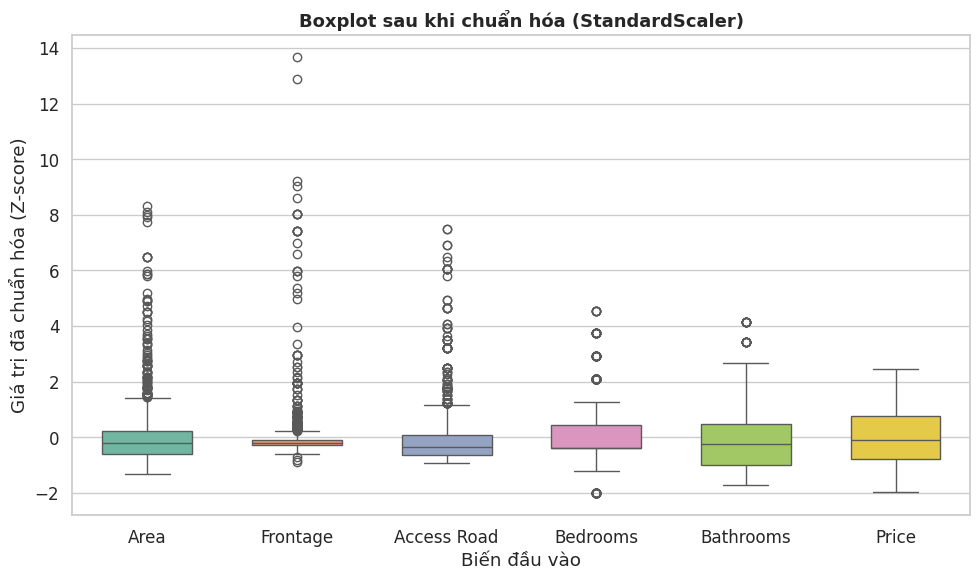

In [182]:
# Vẽ Boxplot sau khi chuẩn hóa
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.boxplot(data=vietnam_housing_clean[cols_to_scale], palette="Set2", width=0.6)
plt.title("Boxplot sau khi chuẩn hóa (StandardScaler)", fontsize=13, fontweight="bold")
plt.ylabel("Giá trị đã chuẩn hóa (Z-score)")
plt.xlabel("Biến đầu vào")
plt.tight_layout()
plt.show()

Trước / Sau: 1772 / 1336


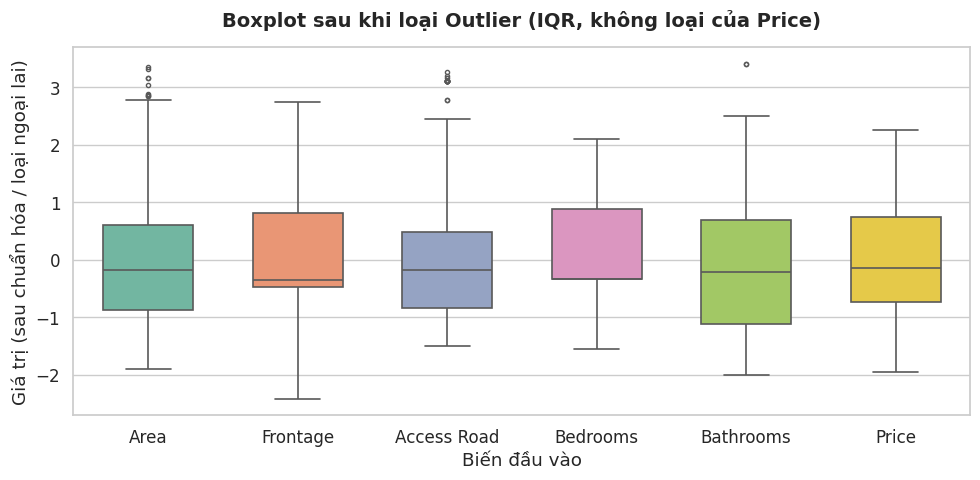

In [183]:
cols = ['Area','Frontage','Access Road','Bedrooms','Bathrooms']

mask = np.ones(len(vietnam_housing_clean), bool)
for c in cols:
    q1, q3 = vietnam_housing_clean[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask &= (vietnam_housing_clean[c] >= q1 - 1.5*iqr) & (vietnam_housing_clean[c] <= q3 + 1.5*iqr)

vietnam_housing_clean = vietnam_housing_clean[mask].copy()
print("Trước / Sau:", len(mask), "/", len(vietnam_housing_clean))

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scale_cols = ['Area','Frontage','Access Road','Bedrooms','Bathrooms','Price']
vietnam_housing_clean[scale_cols] = scaler.fit_transform(vietnam_housing_clean[scale_cols])

## Vẽ Boxplot sau khi loại outlier
# Thiết lập style chung
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)
# Vẽ boxplot dọc
plt.figure(figsize=(10, 5))
sns.boxplot(data=vietnam_housing_clean[scale_cols], width=0.6, fliersize=3, linewidth=1.2)
# Thêm tiêu đề và nhãn trục
plt.title("Boxplot sau khi loại Outlier (IQR, không loại của Price)", fontsize=14, fontweight="bold", pad=15)
plt.ylabel("Giá trị (sau chuẩn hóa / loại ngoại lai)")
plt.xlabel("Biến đầu vào")
# Làm gọn bố cục và hiển thị
plt.tight_layout()
plt.show()


In [185]:
scaler.__dict__

{'with_mean': True,
 'with_std': True,
 'copy': True,
 'feature_names_in_': array(['Area', 'Frontage', 'Access Road', 'Bedrooms', 'Bathrooms',
        'Price'], dtype=object),
 'n_features_in_': 6,
 'n_samples_seen_': np.int64(1308),
 'mean_': array([-0.03293053, -0.01418434, -0.04557154, -0.00780276, -0.00174187,
        -0.01424204]),
 'var_': array([0.93086086, 0.99295334, 0.88216416, 0.98798186, 0.98257003,
        0.99425496]),
 'scale_': array([0.96481131, 0.99647044, 0.93923595, 0.99397277, 0.99124671,
        0.99712334])}

# Vietnam_housing_test

In [186]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Sao chép dữ liệu để không làm thay đổi bản gốc
vietnam_housing_test = pd.DataFrame(vietnam_housing_test)
vietnam_housing_test_clean = vietnam_housing_test.copy()

def find_col(df, name):
    for cand in (name, name.replace(' ', '_'), name.replace(' ', '_').lower()):
        if cand in df.columns:
            return cand
    return None

# Hàm mã hóa hướng an toàn (tạo cột sin/cos với tên có gạch dưới)
def encode_direction(df, name):
    angle_map = {
        'Đông': 0, 'Đông Nam': 45, 'Nam': 90, 'Tây Nam': 135,
        'Tây': 180, 'Tây Bắc': 225, 'Bắc': 270, 'Đông Bắc': 315
    }
    col = find_col(df, name)
    out_base = name.replace(' ', '_')
    if col is None:
        print(f"Warning: direction column not found: {name} -> creating default {out_base}_sin/{out_base}_cos")
        df[out_base + '_sin'] = 0.0
        df[out_base + '_cos'] = 1.0
        return df
    angles = df[col].map(angle_map).fillna(0).astype(float)
    df[out_base + '_sin'] = np.sin(np.deg2rad(angles))
    df[out_base + '_cos'] = np.cos(np.deg2rad(angles))
    return df

# Mã hóa hướng nhà & ban công -
vietnam_housing_test_clean = encode_direction(vietnam_housing_test_clean, 'House direction')
vietnam_housing_test_clean = encode_direction(vietnam_housing_test_clean, 'Balcony direction')

# Mã hóa CÁC BIẾN PHÂN LOẠI KHÁC phân loại khác 
# --- One-Hot Encoding (dành cho các biến phân loại) ---
vietnam_housing_test_clean = pd.get_dummies(
    vietnam_housing_test_clean,
    columns=['Legal status', 'Furniture state'],
    drop_first=True,
    dtype=int
)
vietnam_housing_test_clean.rename(columns={
    'Legal status_Sale contract': 'Legal_status_1',
    'Furniture state_Full': 'Furniture_state_1'
}, inplace=True)

In [187]:
vietnam_housing_test_clean.loc[:, cols_to_scale] = scaler.transform(
    vietnam_housing_test_clean[cols_to_scale]
)

print("Mean sau chuẩn hóa (TEST):")
print(vietnam_housing_test_clean[cols_to_scale].mean().round(2))

print("Std sau chuẩn hóa (TEST):")
print(vietnam_housing_test_clean[cols_to_scale].std().round(2))


Mean sau chuẩn hóa (TEST):
Area           75.13
Frontage        5.57
Access Road     8.46
Bedrooms        3.53
Bathrooms       3.39
Price           5.51
dtype: float64
Std sau chuẩn hóa (TEST):
Area           50.83
Frontage        4.90
Access Road     9.15
Bedrooms        1.12
Bathrooms       1.31
Price           2.27
dtype: float64


/tmp/ipykernel_5343/789269937.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[3.02604142 4.0321052  3.02604142 2.01997764 3.02604142 4.0321052
 4.0321052  4.0321052  3.02604142 3.02604142 4.0321052  4.0321052
 3.02604142 4.0321052  2.01997764 6.04423276 3.02604142 2.01997764
 3.02604142 2.01997764 3.02604142 3.02604142 3.02604142 3.02604142
 1.01391386 2.01997764 4.0321052  5.03816898 3.02604142 4.0321052
 3.02604142 3.02604142 4.0321052  5.03816898 2.01997764 4.0321052
 4.0321052  3.02604142 3.02604142 3.02604142 3.02604142 3.02604142
 2.01997764 3.02604142 3.02604142 4.0321052  3.02604142 3.02604142
 3.02604142 1.01391386 3.02604142 4.0321052  3.02604142 4.0321052
 4.0321052  3.02604142 4.0321052  4.0321052  4.0321052  3.02604142
 2.01997764 4.0321052  4.0321052  3.02604142 3.02604142 4.0321052
 3.02604142 3.02604142 3.02604142 3.02604142 3.02604142 3.02604142
 3.02604142 3.02604142 4.0321052  4.0321052  3.0

In [188]:
# Label Encoding cho Province
from sklearn.preprocessing import LabelEncoder

le_province = LabelEncoder()
vietnam_housing_test_clean["Province_encoded"] = \
    le_province.fit_transform(vietnam_housing_test_clean["Province"])


In [189]:
# Target encoding cho District
!pip install category_encoders
import category_encoders as ce

te = ce.TargetEncoder(cols=["District"])
vietnam_housing_test_clean["District_encoded"] = te.fit_transform(
    vietnam_housing_test_clean["District"], vietnam_housing_test_clean["Price"]
)


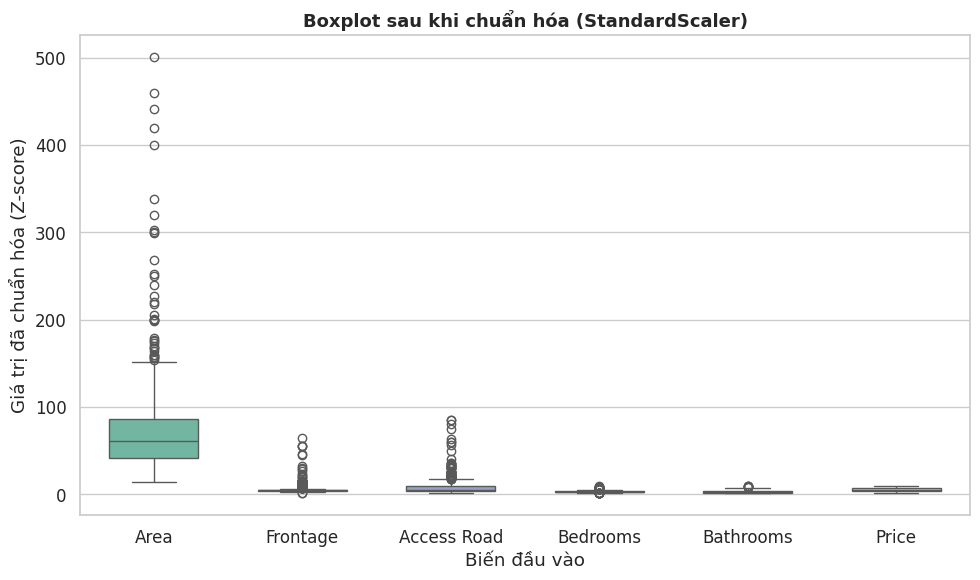

In [190]:
# Vẽ Boxplot sau khi chuẩn hóa
plt.figure(figsize=(10,6))
sns.boxplot(data=vietnam_housing_test[cols_to_scale], palette="Set2", width=0.6)
plt.title("Boxplot sau khi chuẩn hóa (StandardScaler)", fontsize=13, fontweight="bold")
plt.ylabel("Giá trị đã chuẩn hóa (Z-score)")
plt.xlabel("Biến đầu vào")
plt.tight_layout()
plt.show()

Trước / Sau: 874 / 664


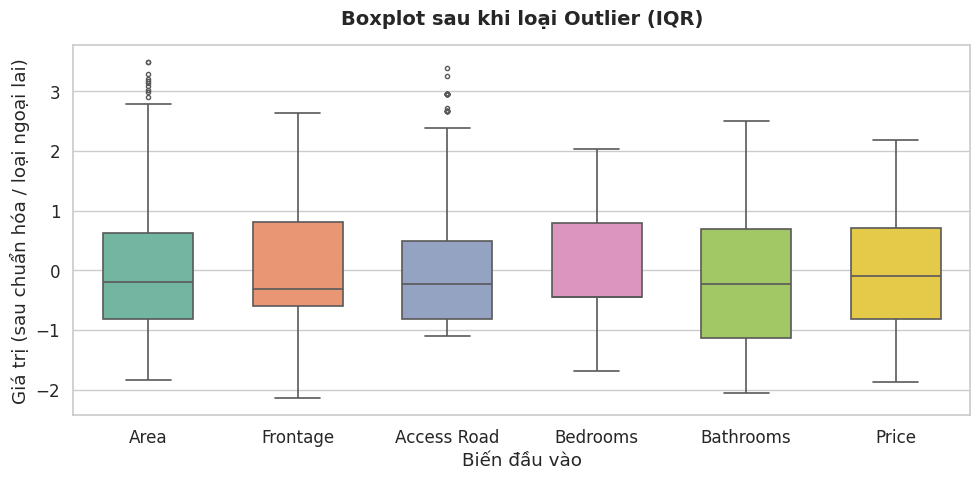

In [191]:
cols = ['Area','Frontage','Access Road','Bedrooms','Bathrooms']

mask = np.ones(len(vietnam_housing_test_clean), bool)
for c in cols:
    q1, q3 = vietnam_housing_test_clean[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask &= (vietnam_housing_test_clean[c] >= q1 - 1.5*iqr) & (vietnam_housing_test_clean[c] <= q3 + 1.5*iqr)

vietnam_housing_test_clean = vietnam_housing_test_clean[mask].copy()
print("Trước / Sau:", len(mask), "/", len(vietnam_housing_test_clean))

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scale_cols = ['Area','Frontage','Access Road','Bedrooms','Bathrooms','Price']
vietnam_housing_test_clean[scale_cols] = scaler.fit_transform(vietnam_housing_test_clean[scale_cols])

## Vẽ Boxplot sau khi loại outlier
# Thiết lập style chung
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)
# Vẽ boxplot dọc
plt.figure(figsize=(10, 5))
sns.boxplot(data=vietnam_housing_test_clean[scale_cols], width=0.6, fliersize=3, linewidth=1.2)
# Thêm tiêu đề và nhãn trục
plt.title("Boxplot sau khi loại Outlier (IQR)", fontsize=14, fontweight="bold", pad=15)
plt.ylabel("Giá trị (sau chuẩn hóa / loại ngoại lai)")
plt.xlabel("Biến đầu vào")
# Làm gọn bố cục và hiển thị
plt.tight_layout()
plt.show()


In [192]:
scaler.__dict__

{'with_mean': True,
 'with_std': True,
 'copy': True,
 'feature_names_in_': array(['Area', 'Frontage', 'Access Road', 'Bedrooms', 'Bathrooms',
        'Price'], dtype=object),
 'n_features_in_': 6,
 'n_samples_seen_': np.int64(664),
 'mean_': array([63.13308544,  4.45209707,  6.22190796,  3.38513346,  3.27893735,
         5.28672423]),
 'var_': array([7.01380327e+02, 5.13247083e-01, 1.34588753e+01, 6.59138687e-01,
        1.22312397e+00, 4.70357518e+00]),
 'scale_': array([26.483586  ,  0.71641265,  3.66863399,  0.81187357,  1.10594935,
         2.16877274])}

In [193]:
vietnam_housing_test_clean[['Frontage','Access Road']].describe()


,Frontage,Access Road
count,6.640000e+02,6.640000e+02
mean,1.605142e-17,1.177104e-16
std,1.000754e+00,1.000754e+00
min,-2.146285e+00,-1.102317e+00
25%,-5.914109e-01,-8.121013e-01
50%,-3.112533e-01,-2.316699e-01
75%,8.093768e-01,4.938693e-01
max,2.630401e+00,3.396026e+00


# THỐNG KÊ MÔ TẢ

In [194]:
from IPython.display import display  

print("Kích thước dữ liệu:", vietnam_housing_clean.shape)
print("\n== Thông tin cột ==")
display(pd.DataFrame({
    "dtype": vietnam_housing_clean.dtypes.astype(str),
    "missing": vietnam_housing_clean.isna().sum(),
    "missing_rate": (vietnam_housing_clean.isna().mean()*100).round(2).astype(str) + "%"
}).sort_index())

Kích thước dữ liệu: (1308, 19)

== Thông tin cột ==


,dtype,missing,missing_rate
Access Road,float64,0,0.0%
Area,float64,0,0.0%
Balcony direction,object,0,0.0%
Balcony_direction_cos,float64,0,0.0%
Balcony_direction_sin,float64,0,0.0%
Bathrooms,float64,0,0.0%
Bedrooms,float64,0,0.0%
District,object,0,0.0%
District_encoded,float64,0,0.0%
Floors,int64,0,0.0%


In [195]:
#Thống kê mô tả cho biến số
num_cols = vietnam_housing_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n== Thống kê biến số ({len(num_cols)} cột) ==")
display(vietnam_housing_clean[num_cols].describe().T)


== Thống kê biến số (15 cột) ==


,count,mean,std,min,25%,50%,75%,max
Area,1308.0,-1.358071e-18,1.000382,-1.930404,-8.666192e-01,-0.185797,0.640764,2.920454
Frontage,1308.0,-8.148426e-18,1.000382,-2.410018,-4.697329e-01,-0.372719,0.823790,2.764075
Access Road,1308.0,-1.290167e-17,1.000382,-1.546421,-8.468269e-01,-0.147233,0.552361,2.651143
Floors,1308.0,3.291284e+00,1.245042,1.000000,2.000000e+00,3.000000,4.000000,7.000000
Bedrooms,1308.0,2.987756e-17,1.000382,-1.552900,-3.263340e-01,-0.326334,0.900232,2.126798
Bathrooms,1308.0,6.790355e-18,1.000382,-2.030211,-1.119540e+00,-0.208869,0.701801,2.523143
Price,1308.0,9.506497e-18,1.000382,-1.953862,-7.343807e-01,-0.164662,0.729939,2.283718
House_direction_sin,1308.0,1.529052e-02,0.444032,-1.000000,0.000000e+00,0.000000,0.000000,1.000000
House_direction_cos,1308.0,6.192661e-01,0.647752,-1.000000,6.123234e-17,1.000000,1.000000,1.000000
Balcony_direction_sin,1308.0,1.987768e-02,0.450693,-1.000000,0.000000e+00,0.000000,0.000000,1.000000


In [196]:
#Thống kê cho biến phân loại (nếu còn)
cat_cols = vietnam_housing_clean.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
if cat_cols:
    print(f"\n== Thống kê biến phân loại ({len(cat_cols)} cột) ==")
    def cat_summary(s: pd.Series):
        vc = s.value_counts(dropna=False)
        return pd.Series({
            "n_unique": s.nunique(dropna=False),
            "top": vc.index[0],
            "top_freq": int(vc.iloc[0]),
            "top_freq_rate": f"{(vc.iloc[0]/len(s)*100):.2f}%"
        })
    display(pd.DataFrame({c: cat_summary(vietnam_housing_clean[c]) for c in cat_cols}).T)
else:
    print("\n== Không còn biến phân loại ==")


== Thống kê biến phân loại (4 cột) ==


,n_unique,top,top_freq,top_freq_rate
Province,29,Hồ Chí Minh,487,37.23%
District,99,Hà Đông,74,5.66%
House direction,8,Đông - Nam,261,19.95%
Balcony direction,8,Đông - Nam,256,19.57%


In [197]:
#Ma trận tương quan nhanh
print("\n== Tương quan giữa các biến số (Top 10 cặp mạnh nhất tuyệt đối) ==")
corr = vietnam_housing_clean[num_cols].corr(numeric_only=True)
corr_abs = corr.abs().where(~np.eye(len(corr), dtype=bool))
pairs = (
    corr_abs.unstack()
    .dropna()
    .sort_values(ascending=False)
    .head(10)
)
display(pairs.to_frame("abs_corr"))


== Tương quan giữa các biến số (Top 10 cặp mạnh nhất tuyệt đối) ==


abs_corr
Balcony_direction_sin House_direction_sin    0.938992
House_direction_sin   Balcony_direction_sin  0.938992
Balcony_direction_cos House_direction_cos    0.934687
House_direction_cos   Balcony_direction_cos  0.934687
Bedrooms              Bathrooms              0.657717
Bathrooms             Bedrooms               0.657717
                      Floors                 0.654862
Floors                Bathrooms              0.654862
Price                 District_encoded       0.527587
District_encoded      Price                  0.527587

# Vẽ pairplot giữa các biến có tương quan cao nhất

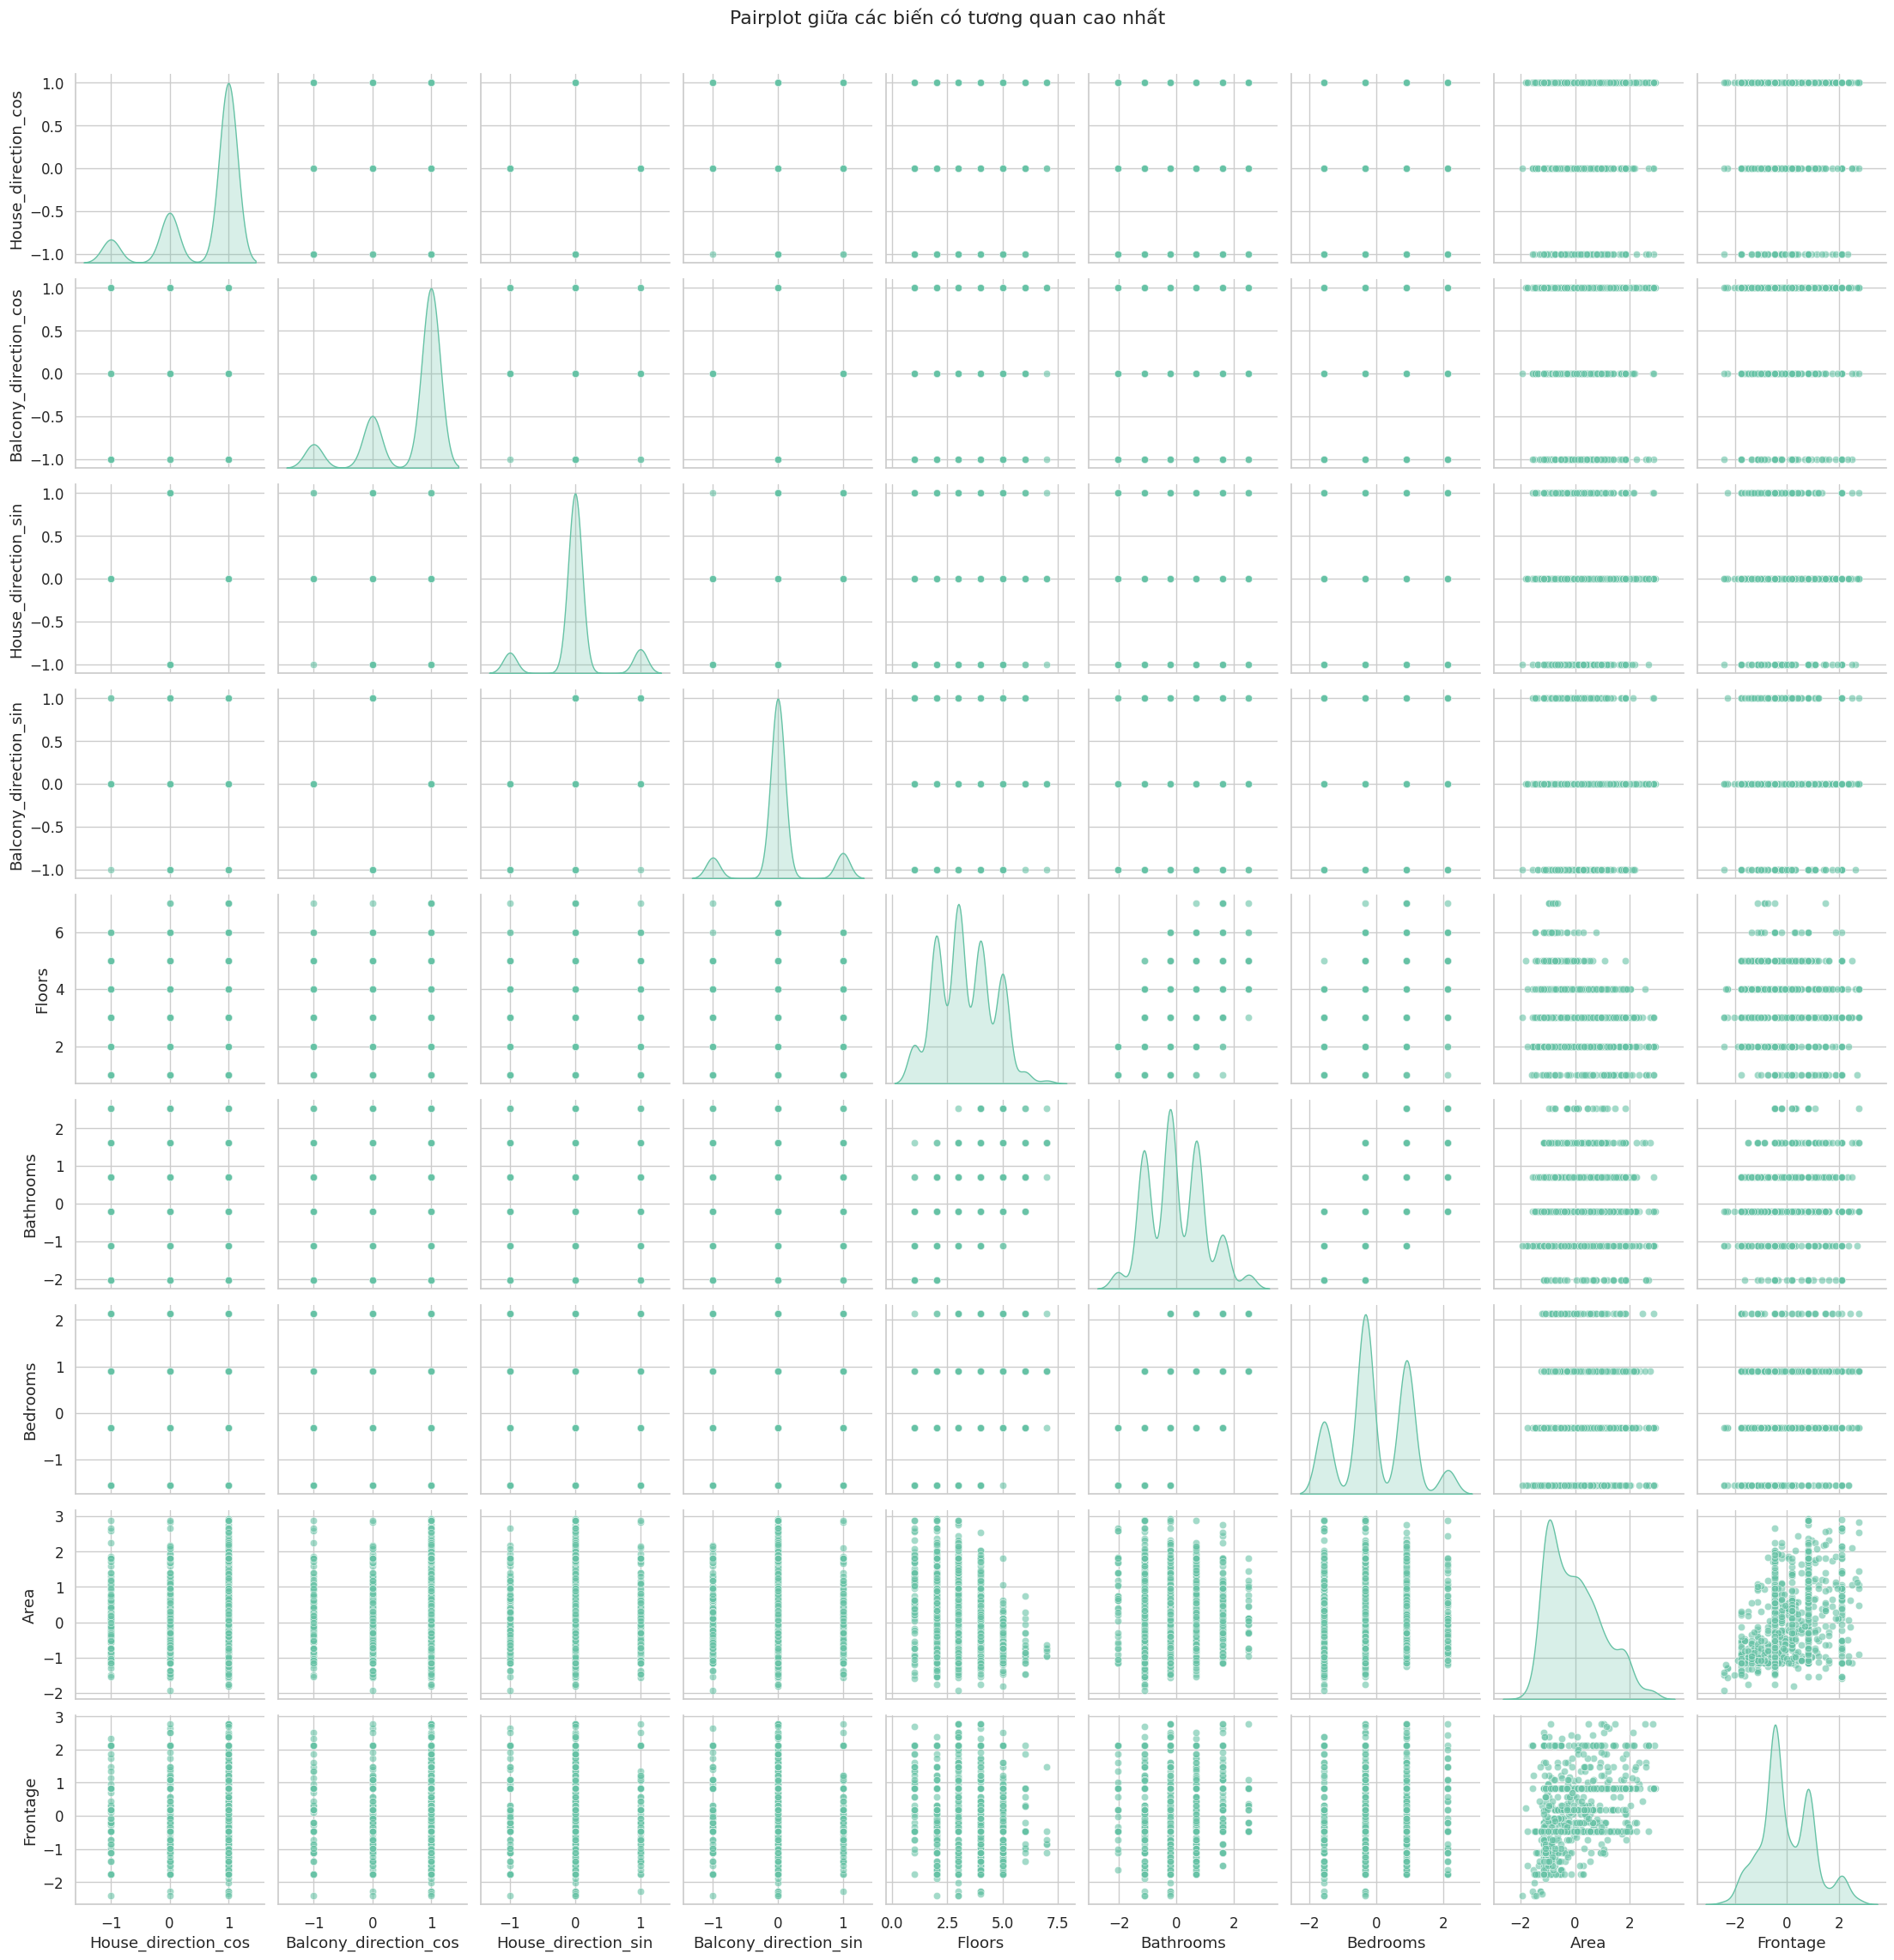

In [198]:
import seaborn as sns
import matplotlib.pyplot as plt


# Danh sách các biến có tương quan cao 
strong_corr_cols = ['House_direction_cos', 'Balcony_direction_cos',
                    'House_direction_sin', 'Balcony_direction_sin',
                    'Floors', 'Bathrooms', 'Bedrooms', 'Area', 'Frontage']

# Vẽ pairplot
sns.pairplot(vietnam_housing_clean[strong_corr_cols], diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle("Pairplot giữa các biến có tương quan cao nhất", y=1.02)
plt.show()

**VISUALIZATION**

**Biểu đồ phân phối (Histogram + KDE) cho các biến số**

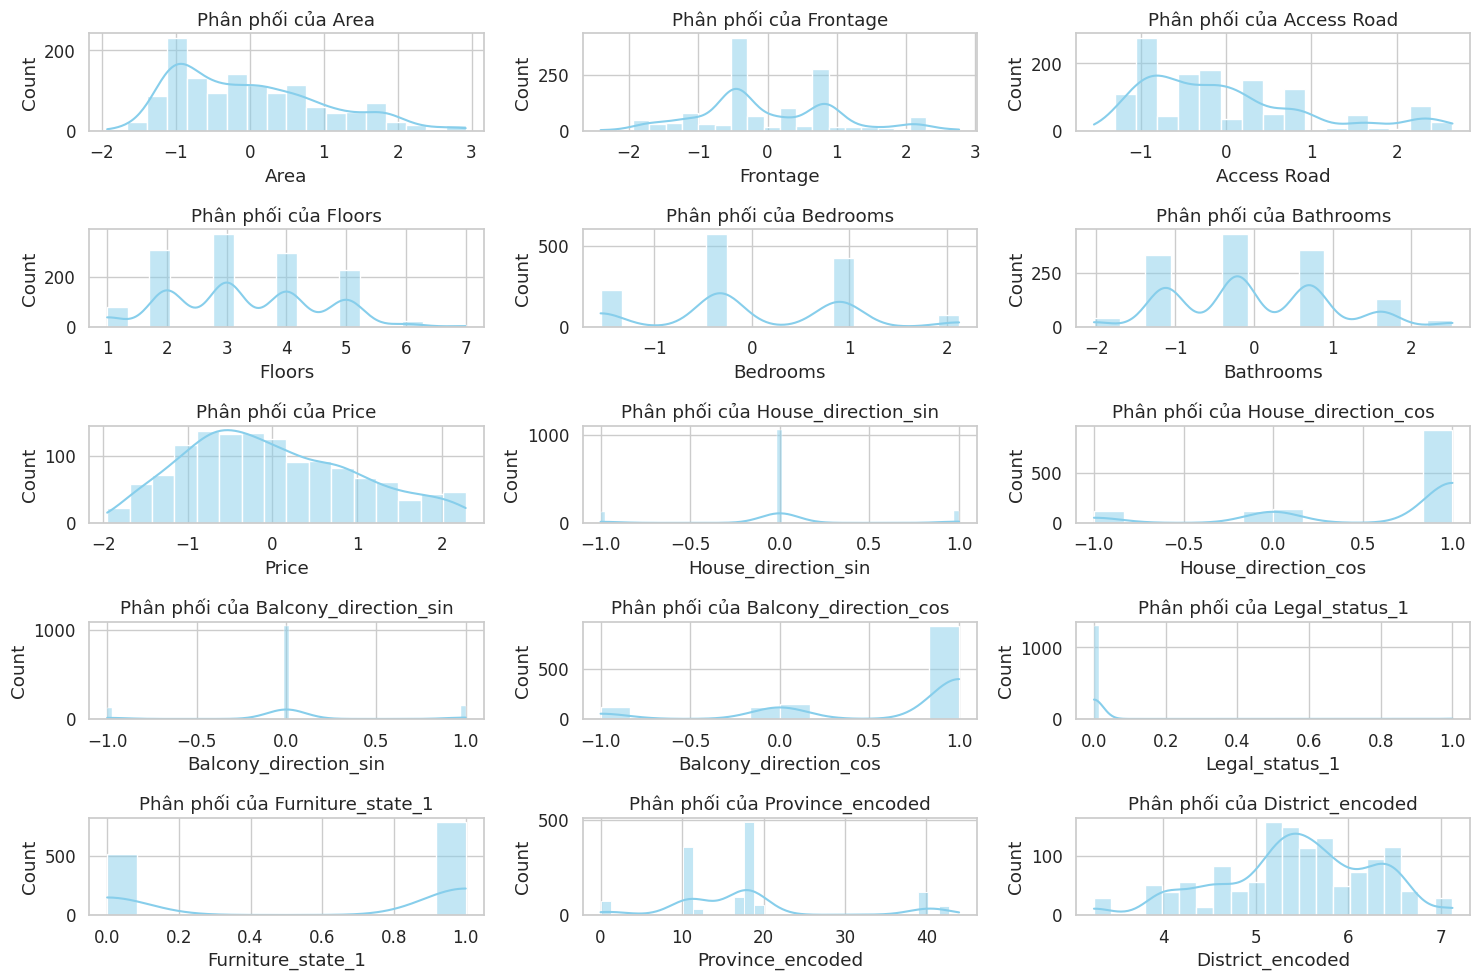

In [199]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = vietnam_housing_clean.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot((len(num_cols) + 2)//3, 3, i + 1)
    sns.histplot(vietnam_housing_clean[col], kde=True, color='skyblue')
    plt.title(f'Phân phối của {col}')
plt.tight_layout()
plt.savefig("phan_phoi_du_lieu.png", dpi=300, bbox_inches='tight')
plt.show()



**Biểu đồ hộp (Boxplot) để phát hiện ngoại lệ**

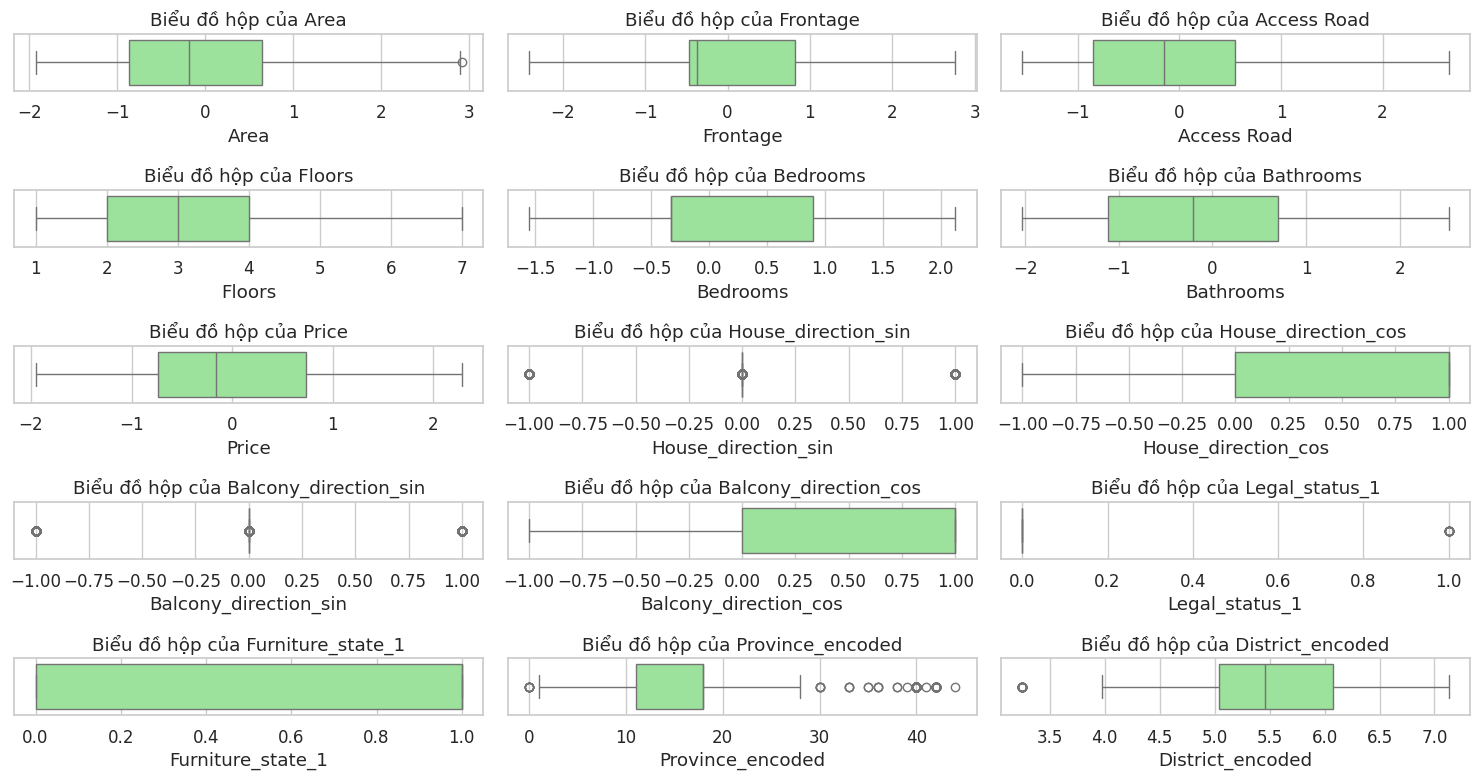

In [200]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols):
    plt.subplot((len(num_cols) + 2)//3, 3, i + 1)
    sns.boxplot(x=vietnam_housing_clean[col], color='lightgreen')
    plt.title(f'Biểu đồ hộp của {col}')
plt.tight_layout()
plt.show()

**Biểu đồ phân tán (Scatter plot) giữa giá và các biến quan trọng**

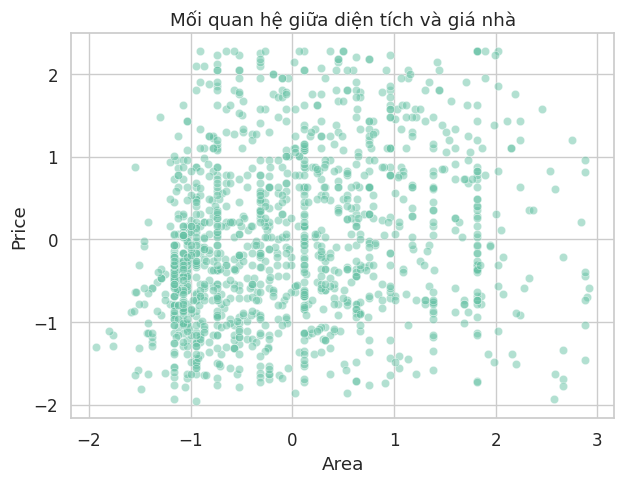

In [201]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='Area', y='Price', data=vietnam_housing_clean, alpha=0.5)
plt.title('Mối quan hệ giữa diện tích và giá nhà')
plt.show()

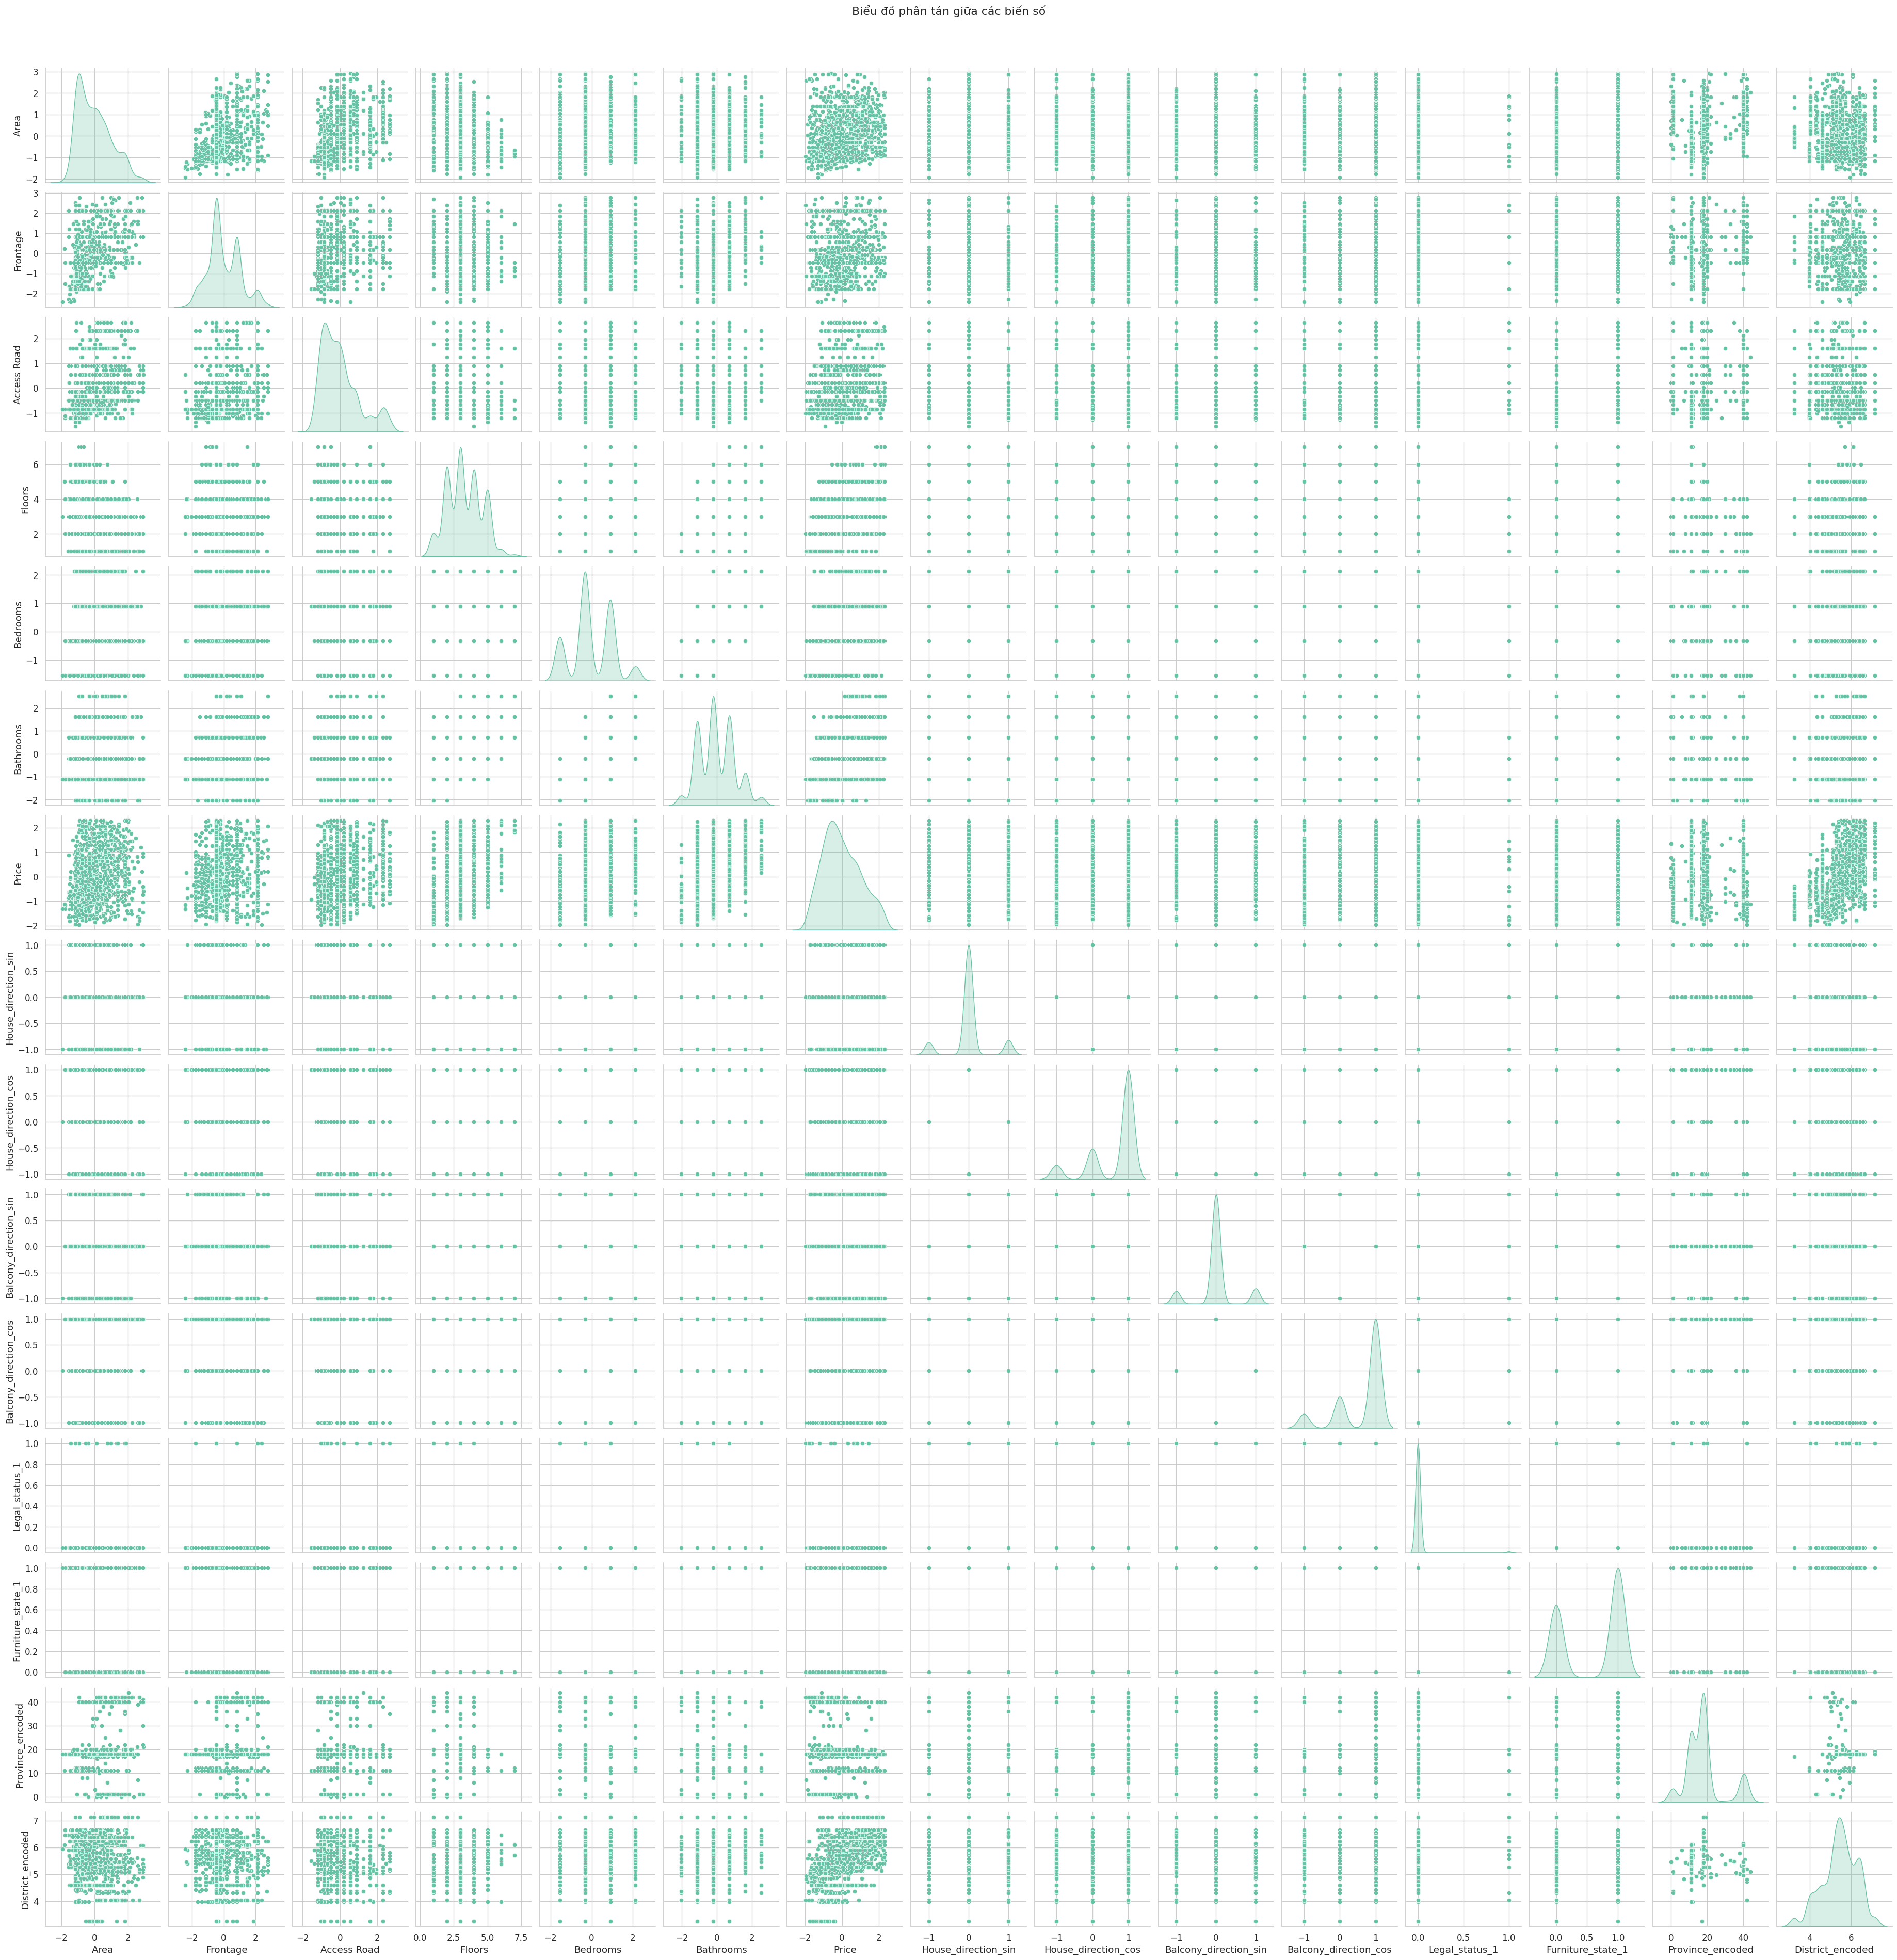

In [202]:
sns.pairplot(vietnam_housing_clean[num_cols], diag_kind='kde')
plt.suptitle('Biểu đồ phân tán giữa các biến số', y=1.02)
plt.show()

**Biểu đồ tương quan (Heatmap)**

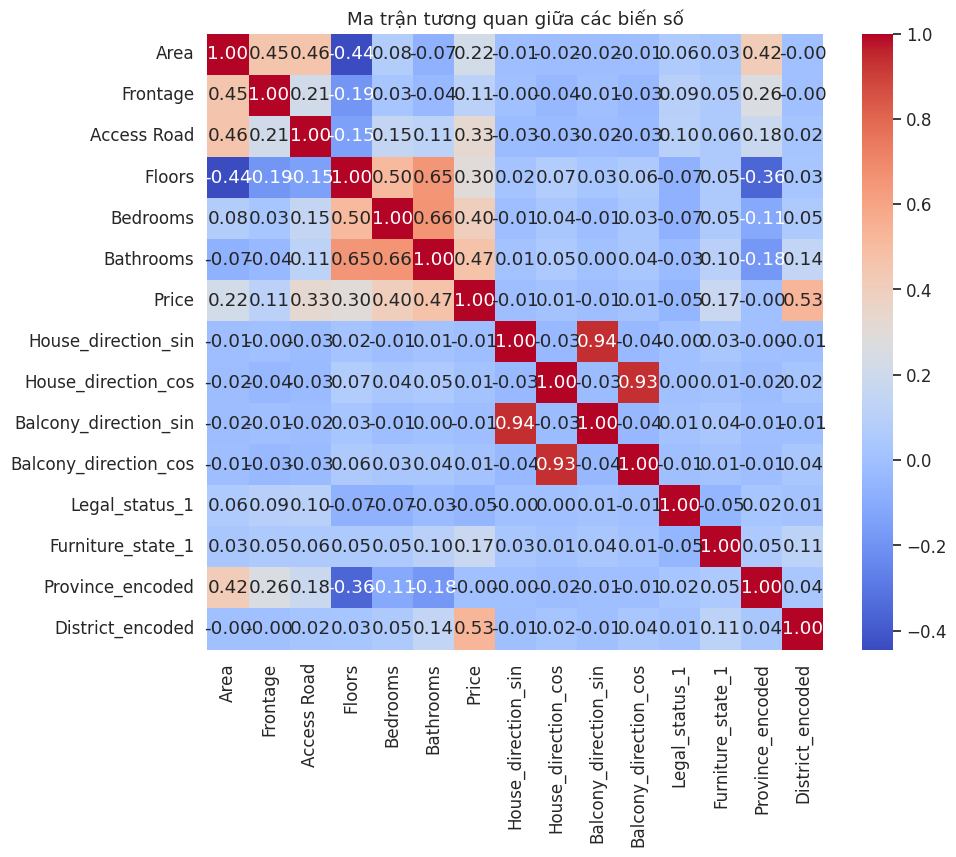

In [203]:
plt.figure(figsize=(10, 8))
corr = vietnam_housing_clean[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

## PHÂN CỤM DỮ LIỆU

In [204]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Định nghĩa các cột số và cột phân loại
num_cols = ['Area', 'Access Road', 'Frontage', 'Bedrooms', 'Bathrooms', 'Price',
            'House_direction_sin', 'House_direction_cos',
            'Balcony_direction_sin', 'Balcony_direction_cos','Legal_status_1','Furniture_status_1','Province_encoded','District_encoded']



In [205]:
num_cols = [c for c in num_cols if c in vietnam_housing_clean.columns]
X = vietnam_housing_clean[num_cols].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [206]:
# Chạy KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
km_inertias, km_scores = [], []
for k in range(3, 10):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    km_inertias.append(km.inertia_)
    km_scores.append(silhouette_score(X_scaled, km.labels_))
    print(f"k={k} | Inertia={km.inertia_:.2f} | Silhouette={km_scores[-1]:.4f}")


k=3 | Inertia=12678.22 | Silhouette=0.1712
k=4 | Inertia=11304.28 | Silhouette=0.1880
k=5 | Inertia=10043.80 | Silhouette=0.1981
k=6 | Inertia=9117.41 | Silhouette=0.2021
k=7 | Inertia=8237.69 | Silhouette=0.2304
k=8 | Inertia=7748.66 | Silhouette=0.2062
k=9 | Inertia=7415.94 | Silhouette=0.1985


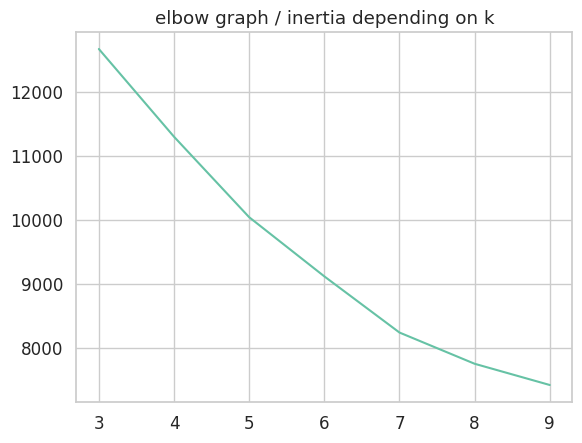

k = 3, Silhouette Score = 0.168
k = 4, Silhouette Score = 0.188
k = 5, Silhouette Score = 0.195
k = 6, Silhouette Score = 0.155
k = 7, Silhouette Score = 0.170
k = 8, Silhouette Score = 0.225
k = 9, Silhouette Score = 0.201


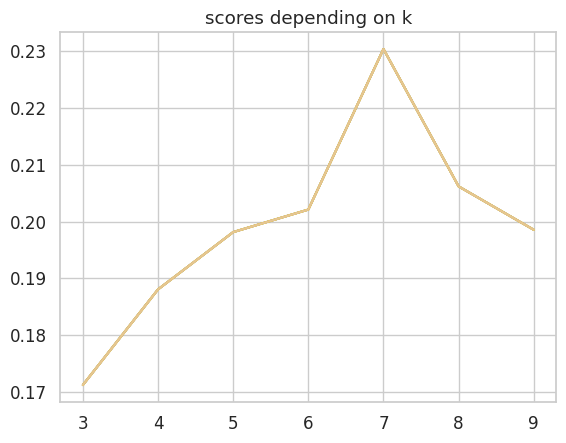

In [207]:
# sns.lineplot(range(3, 10), km_inertias) PHUOCNT
sns.lineplot(x=range(3, 10), y=km_inertias)
plt.title('elbow graph / inertia depending on k')
plt.show()
# Bổ sung kiểm tra bằng Silhouette Score
from sklearn.metrics import silhouette_score
for k in range(3, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    score = silhouette_score(X_scaled, km.labels_)
    print(f"k = {k}, Silhouette Score = {score:.3f}")
    sns.lineplot(x=range(3, 10), y=km_scores)
plt.title('scores depending on k')
plt.show()



In [208]:
# Gán nhãn cho các mẫu dữ liệu dựa vào mô hình K-Means với số cụm là 4 và 5
km = KMeans(n_clusters=4).fit(X_scaled)
#Assign the Cluster Labels to the Data
X['Label'] = km.labels_
clusters = km.labels_
#Info for each cluster
for k in range(4):
 print(f'Cluster nb : {k}')
 print(X[X.Label == k].describe().iloc[:, 1:-1])
 print('\n\n')
 

Cluster nb : 0
       Access Road    Frontage    Bedrooms   Bathrooms       Price  \
count   233.000000  233.000000  233.000000  233.000000  233.000000   
mean      0.085540    0.060778   -0.036801   -0.099433   -0.011830   
std       1.020216    0.991218    1.098306    1.053763    1.029918   
min      -1.196624   -2.410018   -1.552900   -2.030211   -1.930320   
25%      -0.846827   -0.469733   -0.326334   -1.119540   -0.776756   
50%      -0.147233   -0.275704   -0.326334   -0.208869   -0.164662   
75%       0.552361    0.823790    0.900232    0.701801    0.729939   
max       2.651143    2.634723    2.126798    2.523143    2.283718   

       House_direction_sin  House_direction_cos  Balcony_direction_sin  \
count         2.330000e+02         2.330000e+02           2.330000e+02   
mean         -4.935622e-01        -4.892704e-01          -4.935622e-01   
std           5.010349e-01         5.178835e-01           5.010349e-01   
min          -1.000000e+00        -1.000000e+00          -

In [209]:
# Gán nhãn cho các mẫu dữ liệu dựa vào mô hình K-Means với số cụm là 4 và 5
km = KMeans(n_clusters=5).fit(X_scaled)
#Assign the Cluster Labels to the Data
X['Label'] = km.labels_
clusters = km.labels_
#Info for each cluster
for k in range(5):
 print(f'Cluster nb : {k}')
 print(X[X.Label == k].describe().iloc[:, 1:-1])
 print('\n\n')

Cluster nb : 0
       Access Road    Frontage    Bedrooms   Bathrooms       Price  \
count   478.000000  478.000000  478.000000  478.000000  478.000000   
mean     -0.551329   -0.482452   -0.308372   -0.258404   -0.504525   
std       0.595825    0.868060    0.864394    0.758131    0.658306   
min      -1.546421   -2.410018   -1.552900   -2.030211   -1.812609   
25%      -0.846827   -1.116495   -0.326334   -1.119540   -0.965093   
50%      -0.846827   -0.469733   -0.326334   -0.208869   -0.550752   
75%      -0.147233   -0.211028   -0.326334    0.701801   -0.099921   
max       2.301346    2.376018    2.126798    1.612472    2.048297   

       House_direction_sin  House_direction_cos  Balcony_direction_sin  \
count         4.780000e+02           478.000000             478.000000   
mean          6.967927e-19             0.987448               0.008368   
std           6.475239e-02             0.144244               0.144548   
min          -1.000000e+00            -1.000000           

In [210]:
print("KMeans n_clusters:", km.n_clusters)
print("Shape of X_scaled:", X_scaled.shape)

KMeans n_clusters: 5
Shape of X_scaled: (1308, 13)


**VISUALAZATION FOR K- MEANS**

**Biểu đồ T-SNE (2D Scatter Plot)**

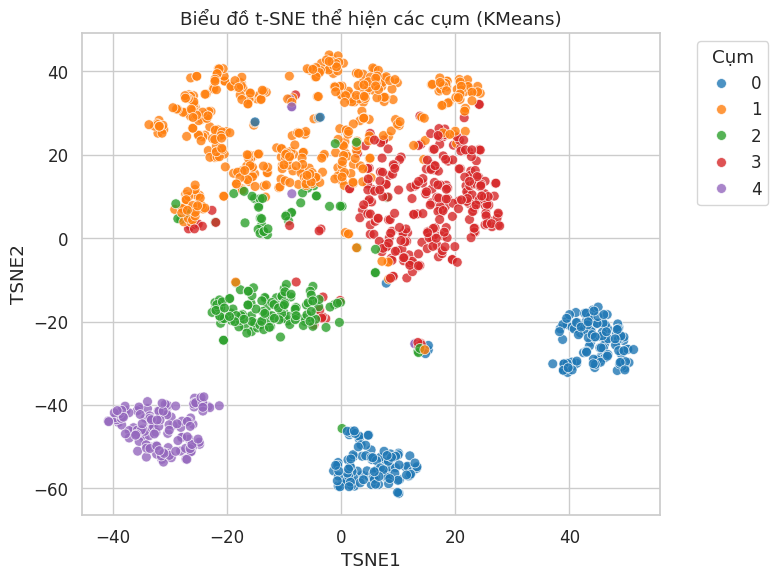

In [211]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cố định random để tái lập kết quả
np.random.seed(42)

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Tạo bản sao dữ liệu
X_plot = X.copy()
X_plot['Label'] = labels  # gắn nhãn cụm vào DataFrame

# Giảm chiều dữ liệu bằng T-SNE để trực quan
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    learning_rate=200
)
X_plot[['TSNE1', 'TSNE2']] = tsne.fit_transform(X_scaled)

# Vẽ biểu đồ t-SNE thể hiện các cụm
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=X_plot,
    x='TSNE1', y='TSNE2',
    hue='Label',
    palette='tab10',
    s=50,
    alpha=0.8
)
plt.title('Biểu đồ t-SNE thể hiện các cụm (KMeans)')
plt.legend(title='Cụm', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Boxplot so sánh các cụm theo từng biến**

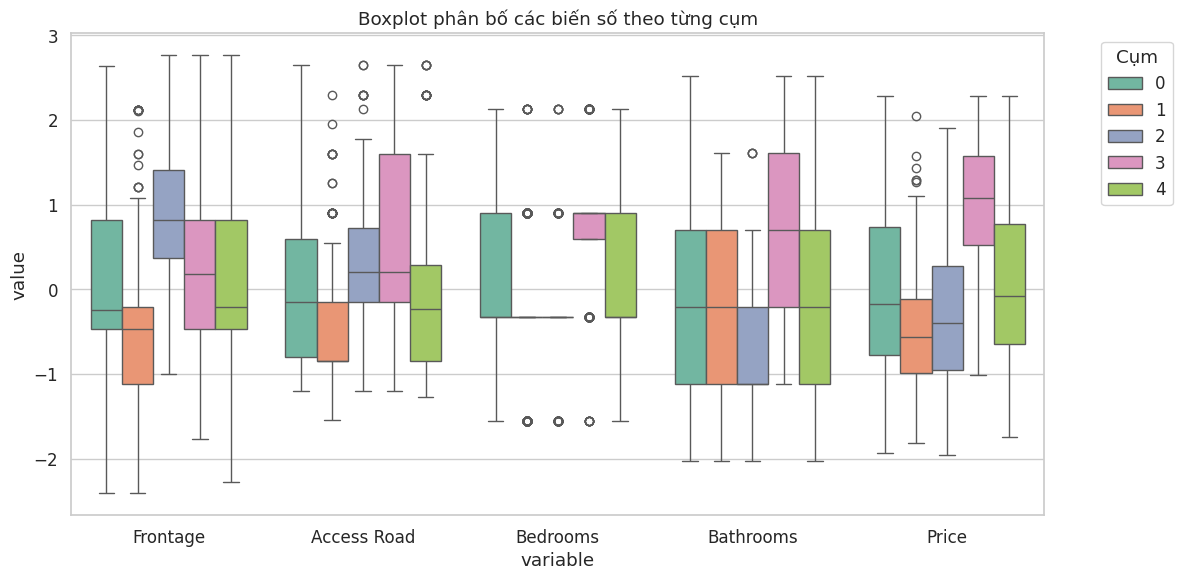

In [212]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
np.random.seed(42)

# Chuẩn bị dữ liệu dạng "long" để vẽ boxplot
melted = X_plot.melt(
    id_vars='Label',
    value_vars=[ 'Frontage', 'Access Road', 'Bedrooms', 'Bathrooms', 'Price']
)

# Vẽ Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=melted, x='variable', y='value', hue='Label', palette='Set2')
plt.title('Boxplot phân bố các biến số theo từng cụm')
plt.legend(title='Cụm', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

**Heatmap trung bình các đặc trưng theo cụm**

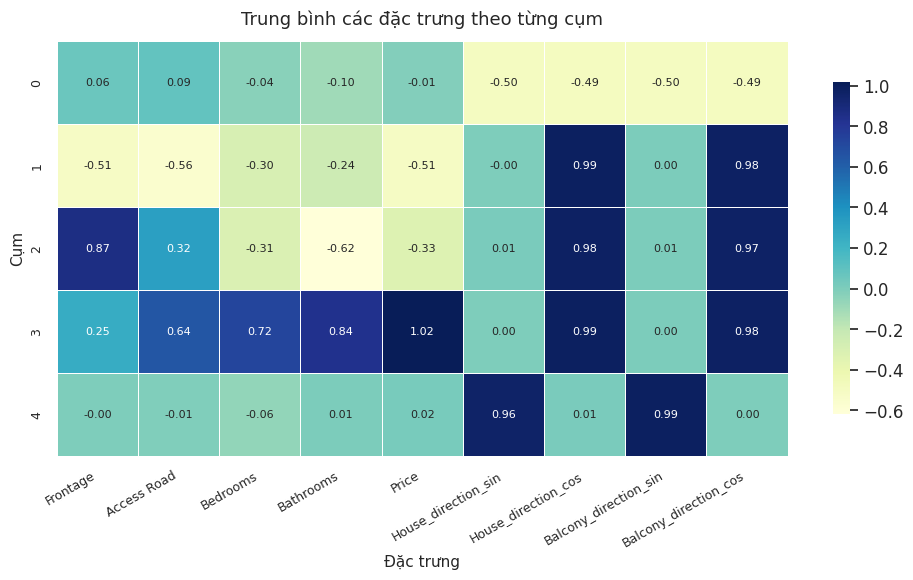

In [213]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính trung bình theo cụm
cluster_means = X_plot.groupby('Label')[[
    'Frontage', 'Access Road', 'Bedrooms', 'Bathrooms', 'Price',
    'House_direction_sin', 'House_direction_cos',
    'Balcony_direction_sin', 'Balcony_direction_cos'
]].mean()

# Tạo figure với kích thước lớn hơn và tỉ lệ cân đối
plt.figure(figsize=(10, 6))

# Vẽ heatmap với định dạng thẩm mỹ hơn
sns.heatmap(
    cluster_means,
    annot=True,               # hiển thị giá trị
    cmap='YlGnBu',            # bảng màu
    fmt=".2f",                # định dạng số
    linewidths=0.5,           # khoảng cách giữa ô
    annot_kws={"size": 8},    # cỡ chữ annotation nhỏ hơn
    cbar_kws={'shrink': 0.8}  # thu nhỏ thanh màu
)

# Tiêu đề và nhãn trục
plt.title('Trung bình các đặc trưng theo từng cụm', fontsize=13, pad=12)
plt.xlabel('Đặc trưng', fontsize=11)
plt.ylabel('Cụm', fontsize=11)

# Xoay nhãn trục X cho dễ đọc
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(fontsize=9)

# Căn chỉnh bố cục
plt.tight_layout()
plt.show()


**Pairplot các biến chính**

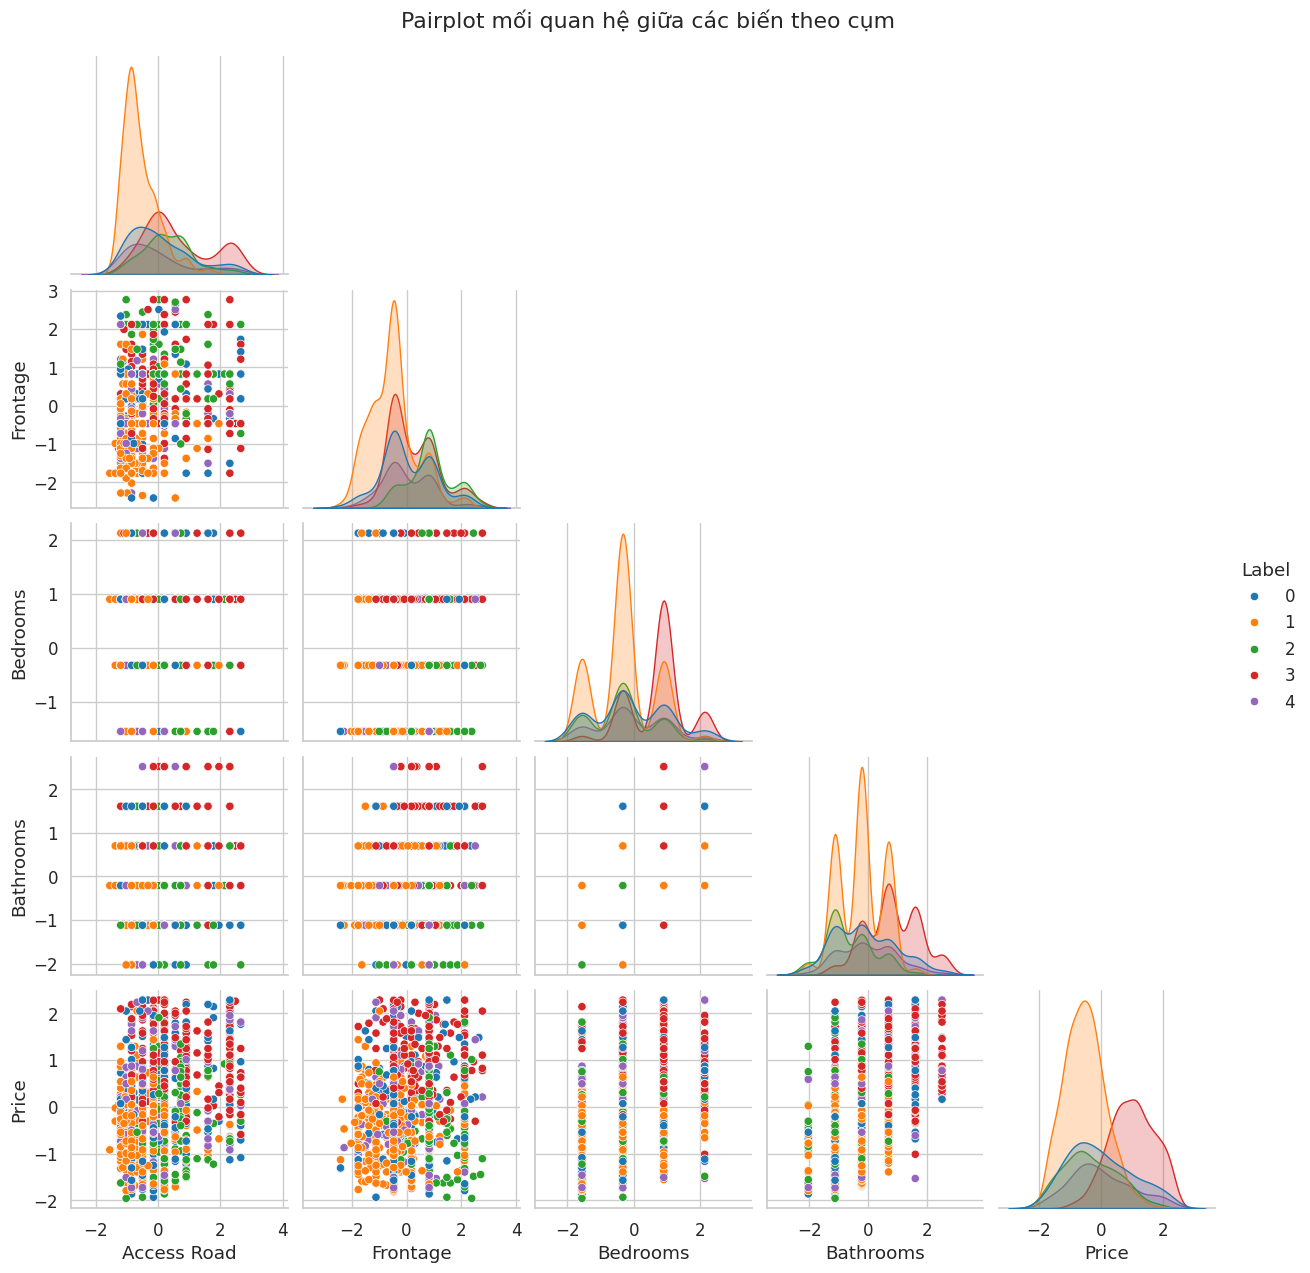

In [214]:
import seaborn as sns

# Chọn subset cột để vẽ 
subset_cols = ['Access Road', 'Frontage', 'Bedrooms', 'Bathrooms', 'Price', 'Label']

sns.pairplot(X_plot[subset_cols], hue='Label', palette='tab10', corner=True)
plt.suptitle('Pairplot mối quan hệ giữa các biến theo cụm', y=1.02)
plt.savefig("pairplot.png")
plt.show()

## DBSCAN

In [215]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [216]:
df = vietnam_housing_clean.copy()
if 'Access Road' in df.columns and 'Access_Road' not in df.columns:
    df = df.rename(columns={'Access Road':'Access_Road'})
if 'Access Road' in df.columns and 'Access_Road' not in df.columns:
    df.rename(columns={'Access Road':'Access_Road'}, inplace=True)

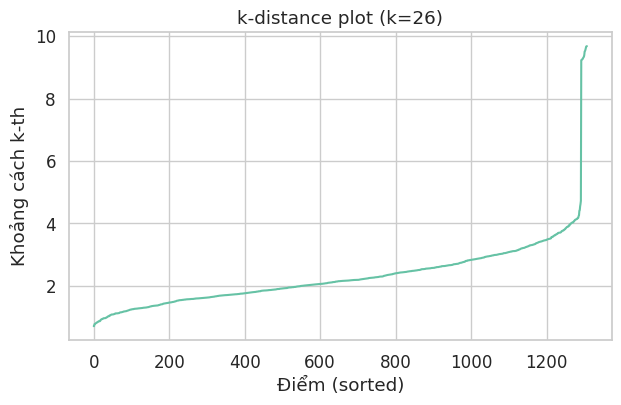

In [217]:
k = max(5, 2*X_scaled.shape[1])  # rule of thumb
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
dist, _ = nbrs.kneighbors(X_scaled)
kdist = np.sort(dist[:, -1])

plt.figure(figsize=(7,4))
plt.plot(kdist); plt.title(f'k-distance plot (k={k})')
plt.xlabel('Điểm (sorted)'); plt.ylabel('Khoảng cách k-th'); plt.show()


In [218]:
for eps_test in [1.2, 1.5, 1.8, 2.0, 2.3, 2.5]:
    db = DBSCAN(eps=eps_test, min_samples=10).fit(X)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = (labels == -1).mean()
    print(f"eps={eps_test}: cụm={n_clusters}, noise={noise:.2%}")


eps=1.2: cụm=8, noise=74.77%
eps=1.5: cụm=11, noise=51.22%
eps=1.8: cụm=13, noise=34.25%
eps=2.0: cụm=14, noise=25.54%
eps=2.3: cụm=7, noise=15.83%
eps=2.5: cụm=5, noise=9.17%


In [219]:
# DBSCAN với eps = 1.5
db = DBSCAN(eps=1.5, min_samples=10).fit(X_scaled)
df['db'] = db.labels_

# K-Means để so sánh
km = KMeans(n_clusters=5, random_state=42).fit(X_scaled)
df['km'] = km.labels_

# Chỉ tính Silhouette nếu DBSCAN ra >=2 cụm khác nhau (bỏ noise -1)
mask = df['db'] != -1
n_clusters_db = len(set(df['db'][mask]))

if n_clusters_db > 1:
    print("Silhouette DBSCAN:", silhouette_score(X[mask], df['db'][mask]))
else:
    print("DBSCAN chỉ có 1 cụm hợp lệ → không tính được Silhouette")

print("Silhouette KMeans:", silhouette_score(X, df['km']))


Silhouette DBSCAN: -0.1355727649610559
Silhouette KMeans: 0.09502830539028378


**VISUALAZATION**

**Biểu đồ phân cụm 2D sau khi giảm chiều (PCA)**

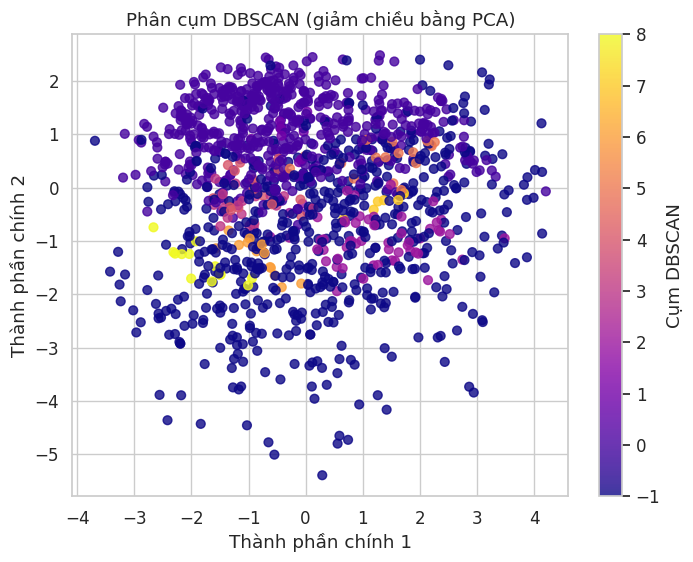

In [220]:
from sklearn.decomposition import PCA

# Giảm chiều dữ liệu để vẽ 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['db'], cmap='plasma', s=40, alpha=0.8)
plt.title('Phân cụm DBSCAN (giảm chiều bằng PCA)')
plt.xlabel('Thành phần chính 1')
plt.ylabel('Thành phần chính 2')
plt.colorbar(label='Cụm DBSCAN')
plt.show()

**So sánh DBSCAN và KMeans trên cùng mặt phẳng PCA**

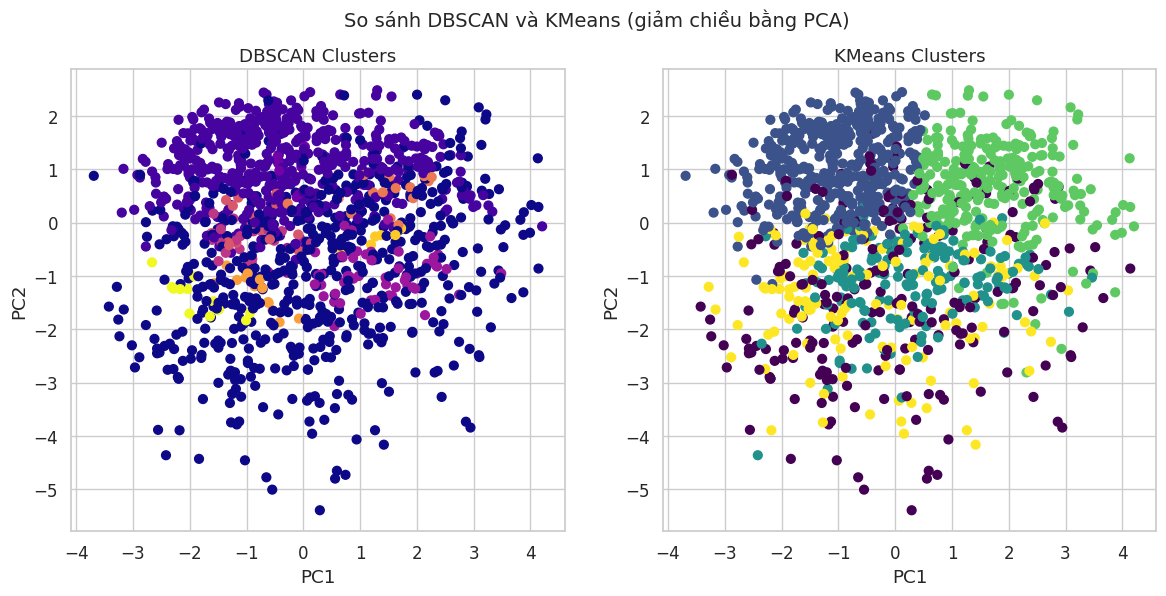

In [221]:
fig, ax = plt.subplots(1, 2, figsize=(14,6))

# DBSCAN
ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['db'], cmap='plasma', s=40)
ax[0].set_title('DBSCAN Clusters')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')

# KMeans
ax[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df['km'], cmap='viridis', s=40)
ax[1].set_title('KMeans Clusters')
ax[1].set_xlabel('PC1')
ax[1].set_ylabel('PC2')

plt.suptitle('So sánh DBSCAN và KMeans (giảm chiều bằng PCA)', fontsize=14)
plt.show()

**Biểu đồ tần suất cụm DBSCAN**

/tmp/ipykernel_5343/3151818732.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='db', data=df, palette='plasma')


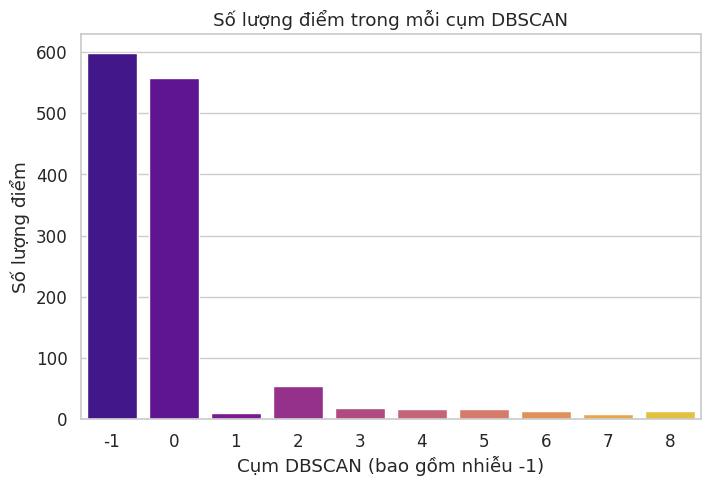

In [222]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='db', data=df, palette='plasma')
plt.title('Số lượng điểm trong mỗi cụm DBSCAN')
plt.xlabel('Cụm DBSCAN (bao gồm nhiễu -1)')
plt.ylabel('Số lượng điểm')
plt.show()

**Trực quan hóa vùng nhiễu**

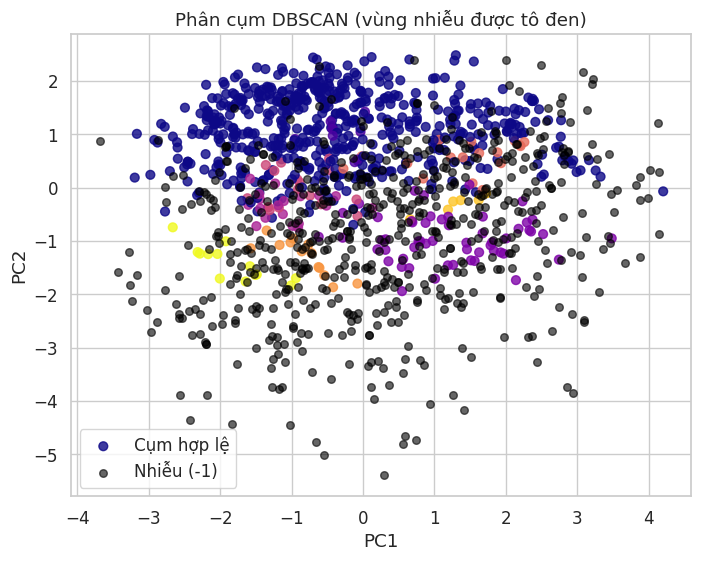

In [223]:
plt.figure(figsize=(8,6))
mask_noise = df['db'] == -1
plt.scatter(X_pca[~mask_noise, 0], X_pca[~mask_noise, 1], c=df['db'][~mask_noise], cmap='plasma', s=40, alpha=0.8, label='Cụm hợp lệ')
plt.scatter(X_pca[mask_noise, 0], X_pca[mask_noise, 1], c='black', s=30, alpha=0.6, label='Nhiễu (-1)')
plt.title('Phân cụm DBSCAN (vùng nhiễu được tô đen)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

## Hierarchical clustering 

In [224]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as pl

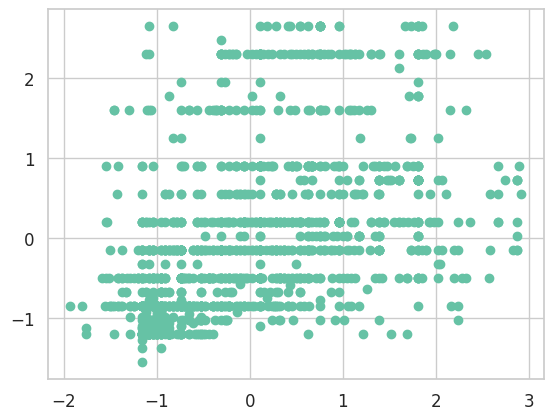

In [225]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
%matplotlib inline
# Generate a random cluster dataset to experiment on. 
# X = coordinate points, y = cluster labels (not needed)
X, y = make_blobs(n_samples=1000, centers=8, n_features=2,
random_state=800)
plt.scatter(X_scaled[:,0], X_scaled[:,1])
plt.show()

In [226]:
# Generate distance matrix with 'linkage' function
distances = linkage(X_scaled, method="centroid", metric="euclidean")
print(distances)

[[2.59000000e+02 1.08700000e+03 0.00000000e+00 2.00000000e+00]
 [7.30000000e+01 2.86000000e+02 0.00000000e+00 2.00000000e+00]
 [3.17000000e+02 7.19000000e+02 0.00000000e+00 2.00000000e+00]
 ...
 [2.61000000e+03 2.61100000e+03 4.94933557e+00 1.29200000e+03]
 [6.20000000e+02 2.60800000e+03 5.34722792e+00 1.60000000e+01]
 [2.61200000e+03 2.61300000e+03 9.24207939e+00 1.30800000e+03]]


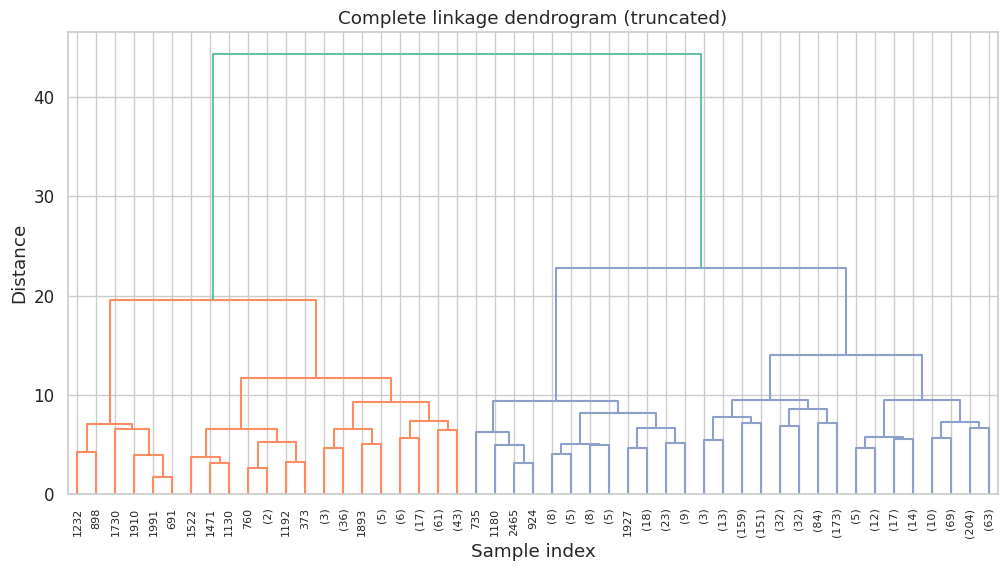

In [227]:
# select numeric columns only (or list the feature column names you want)
numeric_cols = vietnam_housing_clean.select_dtypes(include=[np.number]).columns.tolist()
X_hier = vietnam_housing_clean[numeric_cols].dropna()

if X_hier.shape[0] < 2 or X_hier.shape[1] < 1:
    raise ValueError("Not enough numeric rows/columns for hierarchical clustering. Check vietnam_housing_clean.")

# convert to numpy array (float) for linkage
X_vals = X_hier.values.astype(float)

complete_clustering = linkage(X_vals, method="complete", metric="euclidean")
average_clustering  = linkage(X_vals, method="average",  metric="euclidean")
single_clustering   = linkage(X_vals, method="single",   metric="euclidean")

# optional: plot a truncated dendrogram for the complete linkage
plt.figure(figsize=(12, 6))
dendrogram(complete_clustering, truncate_mode='level', p=5, labels=X_hier.index)
plt.title("Complete linkage dendrogram (truncated)")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()

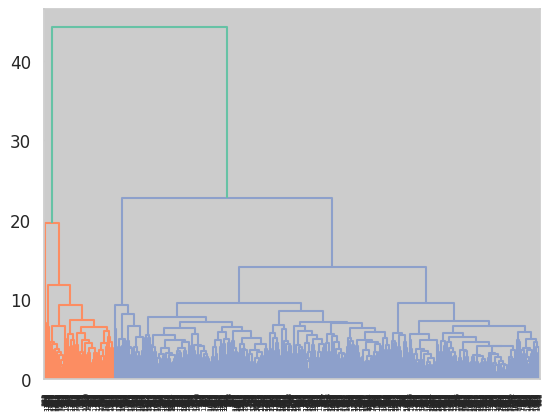

In [228]:
dendrogram(complete_clustering)
plt.show()

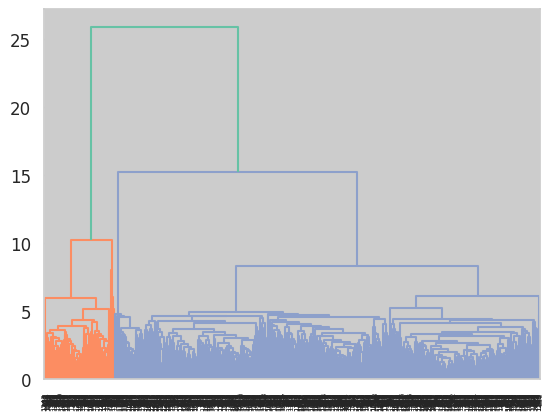

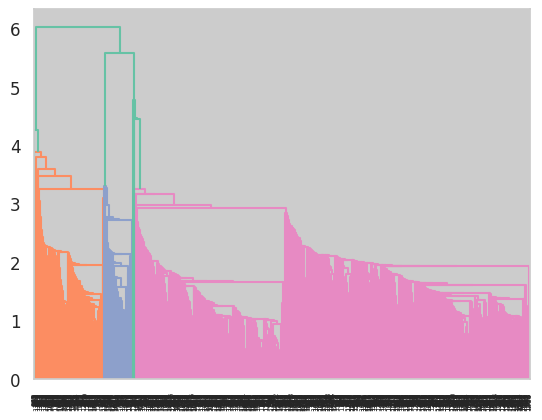

In [229]:
dendrogram(average_clustering)
plt.show()
dendrogram(single_clustering)
plt.show()

best_k=2, silhouette=0.7317


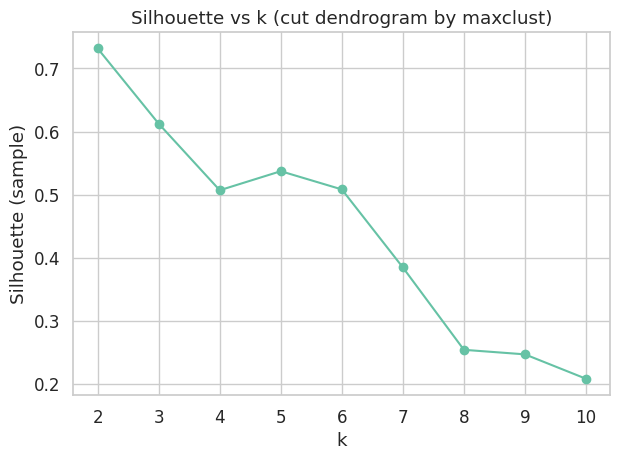

In [230]:
Z = complete_clustering 
# Giả sử `X_hier` là DataFrame
n = len(X_hier)

# Chọn một mẫu ngẫu nhiên (số điểm không quá 2000)
idx = np.random.default_rng(42).choice(n, size=min(2000, n), replace=False)

# Trích xuất mẫu ngẫu nhiên từ X_hier bằng iloc
X_s = X_hier.iloc[idx]  # Sử dụng iloc để trích xuất các hàng theo chỉ số

# Tạo dải giá trị k từ 2 đến 10
k_grid = range(2, 11)

# Tính silhouette score cho mỗi k
sil_scores = [silhouette_score(X_s, fcluster(Z, t=k, criterion="maxclust")[idx]) for k in k_grid]

# Lấy k tối ưu
best_k = list(k_grid)[int(np.nanargmax(sil_scores))]

# In ra kết quả
print(f"best_k={best_k}, silhouette={np.nanmax(sil_scores):.4f}")

# Vẽ đồ thị silhouette score theo k
import matplotlib.pyplot as plt
plt.plot(list(k_grid), sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette (sample)")
plt.title("Silhouette vs k (cut dendrogram by maxclust)")
plt.tight_layout()
plt.show()


In [231]:
labels_ser = pd.Series(labels, index=X_s.index, name="Cluster")
summary_rows = []
for c in sorted(np.unique(labels)):
    mask = (labels_ser.values == c)
    
    # Kiểm tra mask hợp lệ
    print(f"Cluster {c} - Mask shape: {mask.shape}, True count: {mask.sum()}")

    # Lấy median của các cột số trong X_s
    row = {"Cluster": int(c), "Count": int(mask.sum())}
    
    # Dùng iloc đúng cách (mask là mảng NumPy boolean)
    row.update(X_s.iloc[mask][numeric_cols].median().to_dict())
    
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values("Cluster").reset_index(drop=True)

from IPython.display import display
display(summary_df)


Cluster -1 - Mask shape: (1308,), True count: 120
Cluster 0 - Mask shape: (1308,), True count: 609
Cluster 1 - Mask shape: (1308,), True count: 389
Cluster 2 - Mask shape: (1308,), True count: 142
Cluster 3 - Mask shape: (1308,), True count: 38
Cluster 4 - Mask shape: (1308,), True count: 10


,Cluster,Count,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,Price,House_direction_sin,House_direction_cos,Balcony_direction_sin,Balcony_direction_cos,Legal_status_1,Furniture_state_1,Province_encoded,District_encoded
0,-1,120,-0.279410,-0.469733,-0.147233,3.0,-0.326334,-0.208869,-0.070493,0.0,1.0,0.0,1.0,0.0,1.0,17.0,5.495975
1,0,609,-0.185797,-0.340381,-0.147233,3.0,-0.326334,-0.208869,-0.164662,0.0,1.0,0.0,1.0,0.0,1.0,18.0,5.392580
2,1,389,-0.100694,-0.340381,-0.147233,3.0,-0.326334,-0.208869,-0.164662,0.0,1.0,0.0,1.0,0.0,1.0,18.0,5.461706
3,2,142,-0.291750,-0.469733,-0.147233,3.0,-0.326334,-0.208869,-0.098744,0.0,1.0,0.0,1.0,0.0,1.0,18.0,5.572879
4,3,38,0.035470,-0.243366,-0.147233,3.0,-0.326334,-0.208869,-0.211746,0.0,1.0,0.0,1.0,0.0,1.0,17.0,5.699238
5,4,10,-0.128353,-0.340381,-0.497030,3.0,-0.326334,-0.208869,0.044863,0.0,1.0,0.0,1.0,0.0,1.0,18.0,5.597607


/tmp/ipykernel_5343/3459741769.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster", y=target, data=df_cluster, palette="Set2")


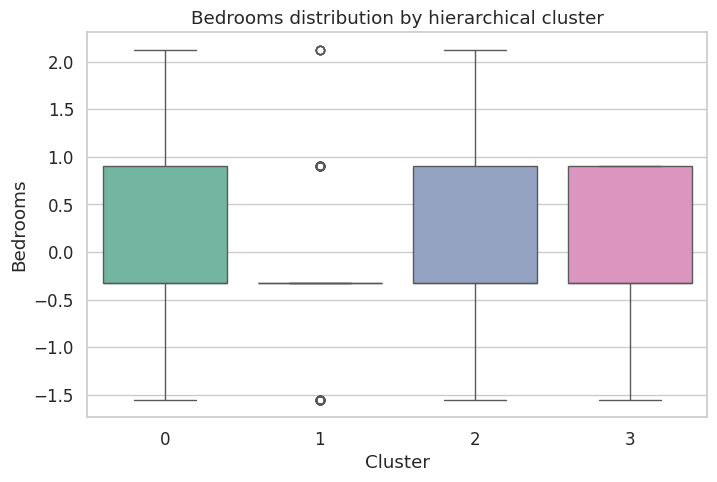

In [232]:
from scipy.cluster.hierarchy import cut_tree
import seaborn as sns
import matplotlib.pyplot as plt
# Cắt cây dendrogram thành 2 cụm (đổi số nếu muốn)
cluster_labels = cut_tree(average_clustering, n_clusters=4).reshape(-1, )

# Gắn nhãn cụm vào dataframe đang dùng (X_hier hoặc vietnam_housing_scaled)
df_cluster = X_hier.copy()
df_cluster["Cluster"] = cluster_labels

# Chọn biến để xem ý nghĩa (ví dụ 'Price')
target = "Bedrooms"

# Vẽ boxplot để so sánh phân bố biến theo cụm
plt.figure(figsize=(8,5))
sns.boxplot(x="Cluster", y=target, data=df_cluster, palette="Set2")
plt.title(f"{target} distribution by hierarchical cluster")
plt.show()

In [233]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
# 1. Chuẩn hóa
X = vietnam_housing_clean[num_cols].dropna()
X_scaled = StandardScaler().fit_transform(X)
# 2. Linkage
Z = linkage(X_scaled, method='ward')
# 3. Cắt cụm (ví dụ 4 cụm)
labels = fcluster(Z, t=2, criterion='maxclust')
# 4. Silhouette Score
sil_score = silhouette_score(X_scaled, labels)
print("✅ Silhouette Score:", sil_score)

✅ Silhouette Score: 0.24556531652874508


✅ Best k (Ward linkage) = 4, Silhouette = 0.2632


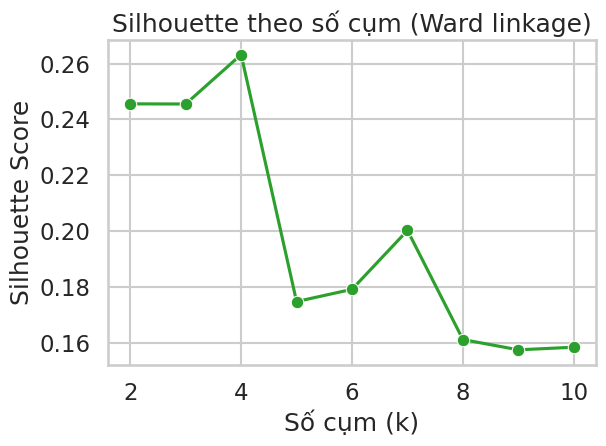

In [234]:
# Ward linkage
Z = linkage(X_scaled, method='ward')

# Lấy mẫu ngẫu nhiên tối đa 2000 điểm
n = len(X_scaled)
idx = np.random.default_rng(42).choice(n, size=min(2000, n), replace=False)
X_s = X_scaled[idx]

# Tính silhouette cho từng k
k_grid = range(2, 11)
sil_scores = [silhouette_score(X_s, fcluster(Z, t=k, criterion="maxclust")[idx]) for k in k_grid]

# Xác định k tối ưu
best_k = list(k_grid)[int(np.nanargmax(sil_scores))]
print(f"✅ Best k (Ward linkage) = {best_k}, Silhouette = {np.nanmax(sil_scores):.4f}")

# Vẽ biểu đồ
sns.set(style="whitegrid", context="talk")
sns.lineplot(x=list(k_grid), y=sil_scores, marker='o', color="#2ca02c")
plt.title("Silhouette theo số cụm (Ward linkage)")
plt.xlabel("Số cụm (k)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()


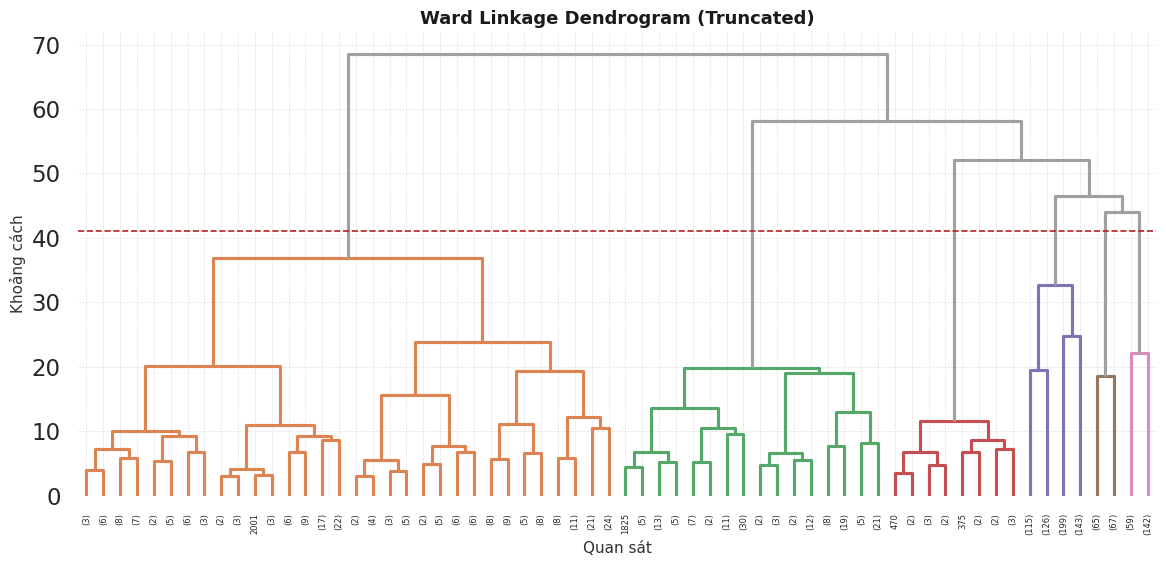

In [235]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6), facecolor='white')

# Dendrogram Ward linkage (rút gọn)
dendrogram(
    Z,
    truncate_mode='level',
    p=5,
    labels=X_hier.index,
    color_threshold=0.6 * max(Z[:, 2]),
    above_threshold_color="#A0A0A0"
)

# Tiêu đề & nhãn
plt.title("Ward Linkage Dendrogram (Truncated)", fontsize=13, fontweight='bold', color='#1A1A1A')
plt.xlabel("Quan sát", fontsize=11, color="#333333")
plt.ylabel("Khoảng cách", fontsize=11, color="#333333")

# Đường cắt cụm đỏ
plt.axhline(y=0.6 * max(Z[:, 2]), color="#B22222", linestyle="--", linewidth=1.2)

# Lưới nhẹ & nền trắng
plt.grid(True, linestyle='--', linewidth=0.5, color="#E0E0E0")
plt.gca().set_facecolor('white')
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


In [236]:
for k in range(2, 7):
    labels_hier = fcluster(Z, t=k, criterion='maxclust')
    silhouette = silhouette_score(X_scaled, labels_hier)
    print(f"Silhouette Score for k={k}: {silhouette:.4f}")


Silhouette Score for k=2: 0.2456
Silhouette Score for k=3: 0.2455
Silhouette Score for k=4: 0.2632
Silhouette Score for k=5: 0.1747
Silhouette Score for k=6: 0.1791


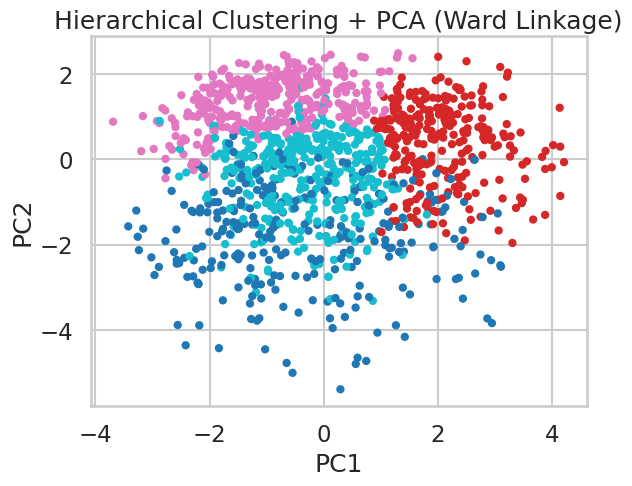

In [237]:
from sklearn.decomposition import PCA

# Chọn số lượng thành phần PCA nhỏ hơn hoặc bằng số đặc trưng trong dữ liệu (ở đây là 5)
pca = PCA(n_components=3)  # Hoặc có thể chọn n_components=2 để giảm xuống 2 chiều
X_reduced = pca.fit_transform(X_scaled)

# Tiến hành phân cụm với dữ liệu giảm chiều
Z = linkage(X_reduced, method='ward')

# Cắt cụm với số cụm tùy chọn
labels_hier = fcluster(Z, t=4, criterion='maxclust')

# Hiển thị kết quả trực quan
pca = PCA(n_components=2)  # Giảm xuống 2 chiều để trực quan hóa
X_pca = pca.fit_transform(X_scaled)

# Vẽ scatter plot với các cụm khác nhau
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_hier, cmap='tab10', s=20)
plt.title("Hierarchical Clustering + PCA (Ward Linkage)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()



In [238]:

# Cắt cây phân cụm theo k tối ưu (Ward linkage)
labels = fcluster(Z, t=best_k, criterion='maxclust')

# Kiểm tra số cụm và phân bố
print(f"Số cụm được hình thành (Ward): {len(np.unique(labels))}")
print("Phân bố số lượng quan sát trong từng cụm:", np.unique(labels, return_counts=True))



Số cụm được hình thành (Ward): 4
Phân bố số lượng quan sát trong từng cụm: (array([1, 2, 3, 4], dtype=int32), array([274, 286, 386, 362]))


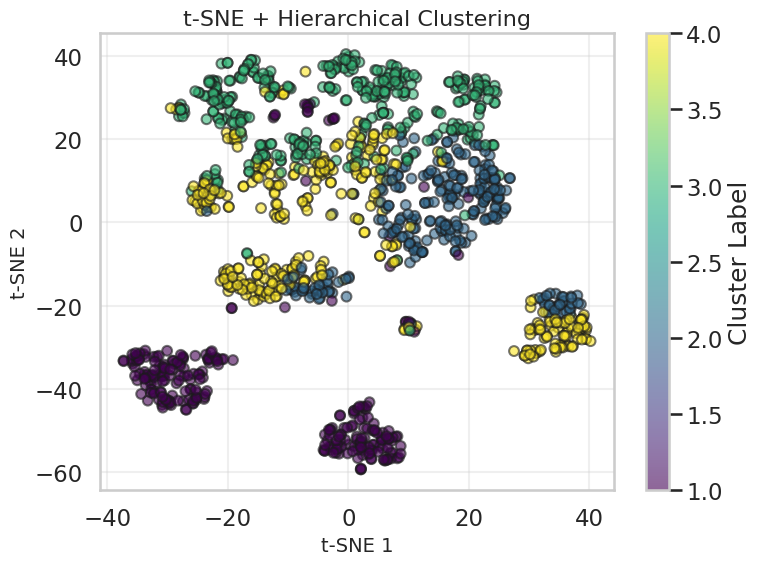

In [239]:
from sklearn.manifold import TSNE

# Áp dụng t-SNE để giảm chiều xuống 2D
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Vẽ scatter plot sau khi giảm chiều bằng t-SNE
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_hier, cmap='viridis', s=50, alpha=0.6, edgecolors='k')
plt.title("t-SNE + Hierarchical Clustering", fontsize=16)
plt.xlabel("t-SNE 1", fontsize=14)
plt.ylabel("t-SNE 2", fontsize=14)
plt.colorbar(label='Cluster Label')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


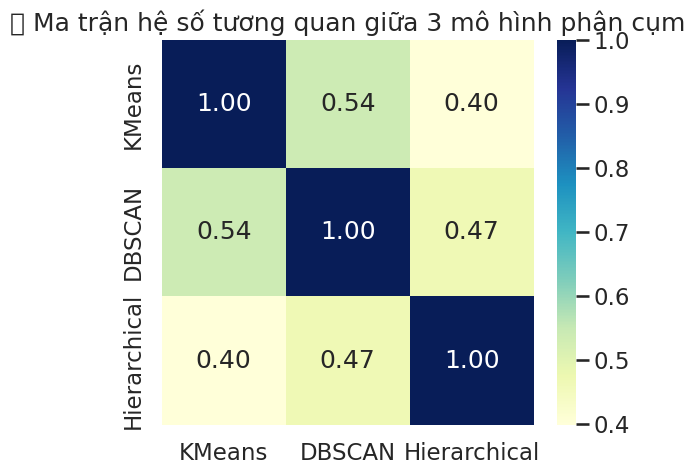

✅ Ma trận tương quan giữa các phương pháp phân cụm:


,KMeans,DBSCAN,Hierarchical
KMeans,1.000000,0.537877,0.398706
DBSCAN,0.537877,1.000000,0.467646
Hierarchical,0.398706,0.467646,1.000000


In [240]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Giả sử các nhãn đã có:
# df['km'] – KMeans
# df['db'] – DBSCAN
# df_cluster['Cluster'] – Hierarchical

# 1️⃣ Gộp nhãn lại thành một DataFrame chung
compare_df = pd.DataFrame({
    'KMeans': df['km'].values,
    'DBSCAN': df['db'].values,
    'Hierarchical': df_cluster['Cluster'].reindex(df.index, fill_value=-1).values
})

# 2️⃣ Đảm bảo các giá trị đều là số (tránh lỗi khi tính)
for col in compare_df.columns:
    le = LabelEncoder()
    compare_df[col] = le.fit_transform(compare_df[col])

# 3️⃣ Hàm tính Cramér’s V giữa hai phân cụm
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# 4️⃣ Tạo ma trận hệ số tương quan
methods = ['KMeans', 'DBSCAN', 'Hierarchical']
coef_matrix = pd.DataFrame(index=methods, columns=methods, dtype=float)

for i in methods:
    for j in methods:
        coef_matrix.loc[i, j] = cramers_v(compare_df[i], compare_df[j])

# 5️⃣ Hiển thị ma trận
plt.figure(figsize=(6,5))
sns.heatmap(coef_matrix.astype(float), annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("🔹 Ma trận hệ số tương quan giữa 3 mô hình phân cụm")
plt.show()

# 6️⃣ In kết quả chi tiết
print("✅ Ma trận tương quan giữa các phương pháp phân cụm:")
display(coef_matrix)


In [241]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

# Giả sử các nhãn đã có
labels_km = df['km']
labels_db = df['db']
labels_hier = df_cluster['Cluster'].reindex(df.index, fill_value=-1)  # 🔁 đồng bộ index

# Loại bỏ noise trong DBSCAN
mask = labels_db != -1

# Lọc 3 nhãn theo mask (sử dụng .loc để tránh lỗi index)
labels_db_clean = labels_db.loc[mask]
labels_km_clean = labels_km.loc[mask]
labels_hier_clean = labels_hier.loc[mask]

# ✅ Tính ARI và AMI
compare_metrics = pd.DataFrame({
    "Model Comparison": [
        "KMeans vs DBSCAN",
        "KMeans vs Hierarchical",
        "DBSCAN vs Hierarchical"
    ],
    "ARI": [
        adjusted_rand_score(labels_km_clean, labels_db_clean),
        adjusted_rand_score(labels_km, labels_hier),
        adjusted_rand_score(labels_db_clean, labels_hier_clean)
    ],
    "AMI": [
        adjusted_mutual_info_score(labels_km_clean, labels_db_clean),
        adjusted_mutual_info_score(labels_km, labels_hier),
        adjusted_mutual_info_score(labels_db_clean, labels_hier_clean)
    ]
})
print(compare_metrics)



         Model Comparison       ARI       AMI
0        KMeans vs DBSCAN  0.423944  0.544301
1  KMeans vs Hierarchical  0.112752  0.176440
2  DBSCAN vs Hierarchical  0.611367  0.585572


**VISUALIZATION**

**Phân bố cụm (Scatter Plot)**

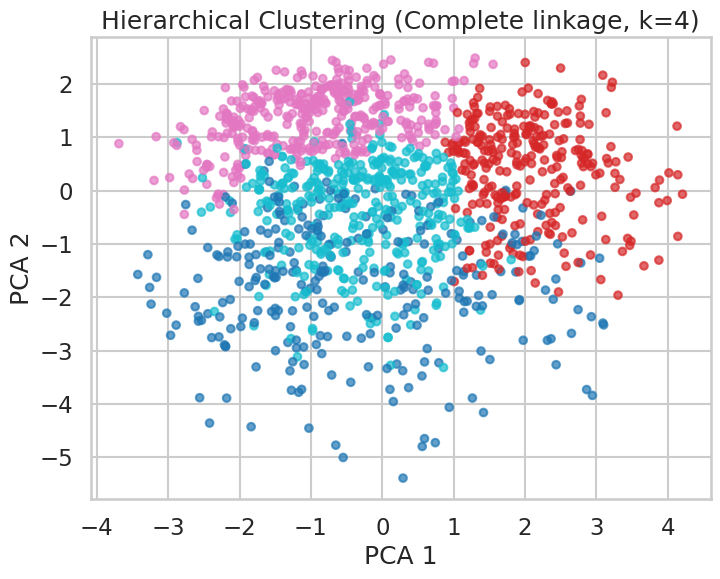

In [242]:
from sklearn.decomposition import PCA

# Giảm về 2 chiều để vẽ
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_s)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels[idx], cmap='tab10', s=30, alpha=0.7)
plt.title(f"Hierarchical Clustering (Complete linkage, k={best_k})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

**Boxplot mô tả đặc trưng từng cụm**

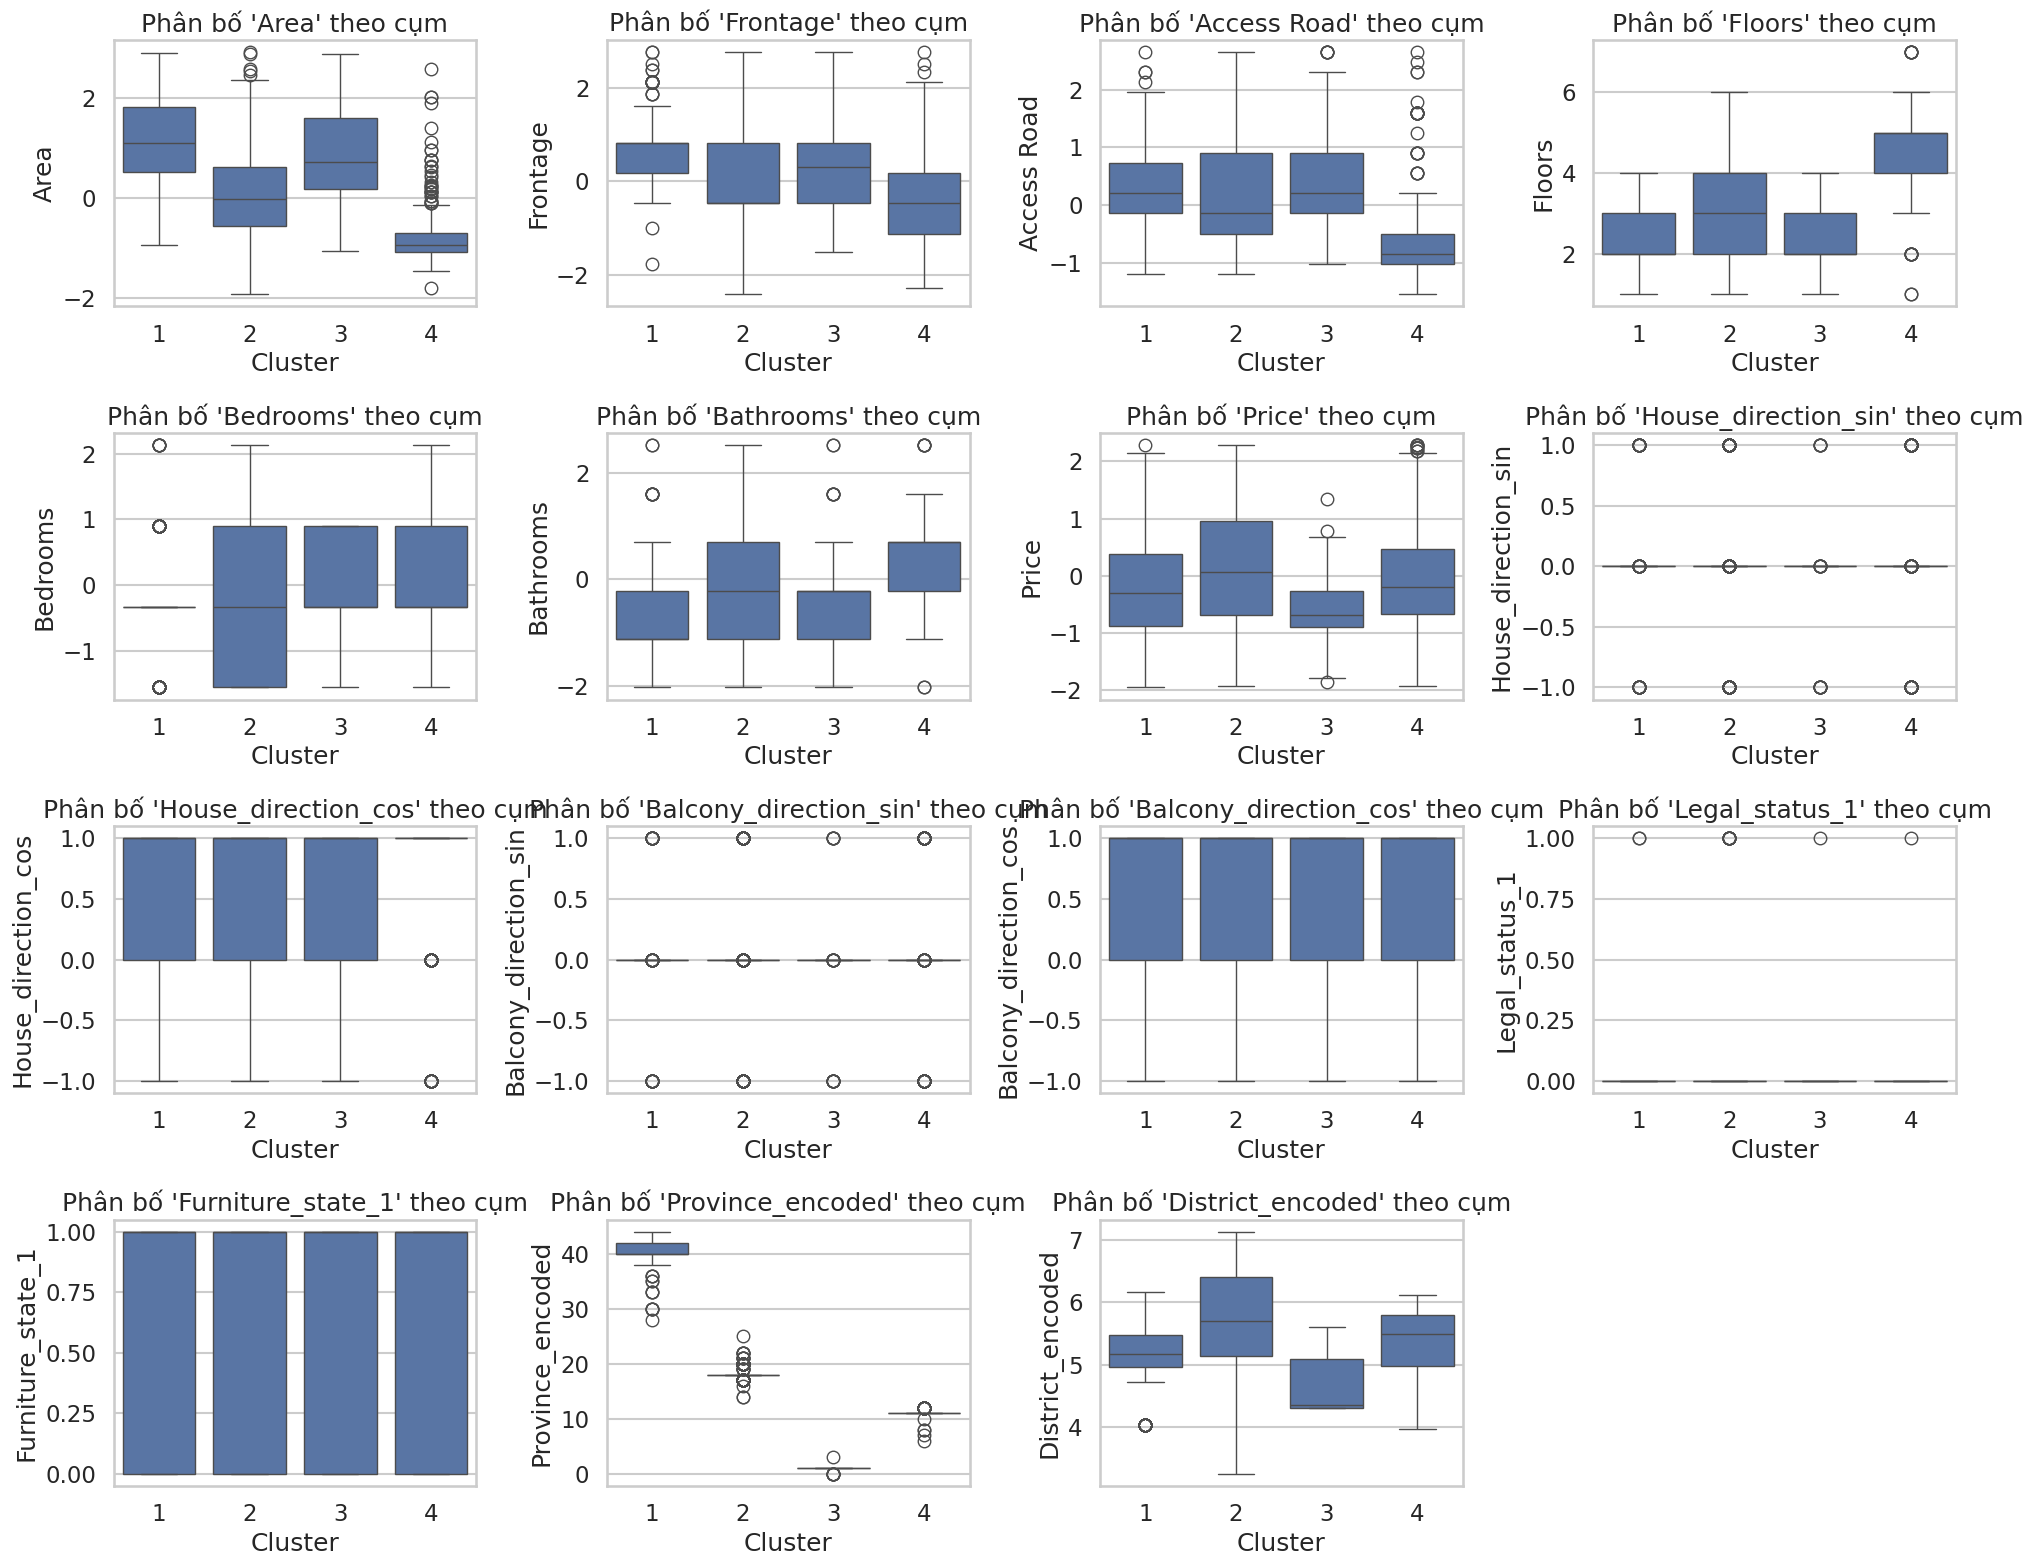

In [243]:

from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(X_hier, method='ward')  

# Sau đó gán nhãn cụm
clustered = X_hier.copy()
clustered['Cluster'] = fcluster(Z, t=4, criterion='maxclust')  

# Vẽ boxplot cho tất cả các biến (trừ Cluster)
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [col for col in clustered.columns if col != 'Cluster']

n_cols = 4
n_rows = -(-len(numeric_cols) // n_cols)
plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=clustered, x='Cluster', y=col)
    plt.title(f"Phân bố '{col}' theo cụm")

plt.tight_layout()
plt.show()


**Heatmap trung vị đặc trưng cụm**

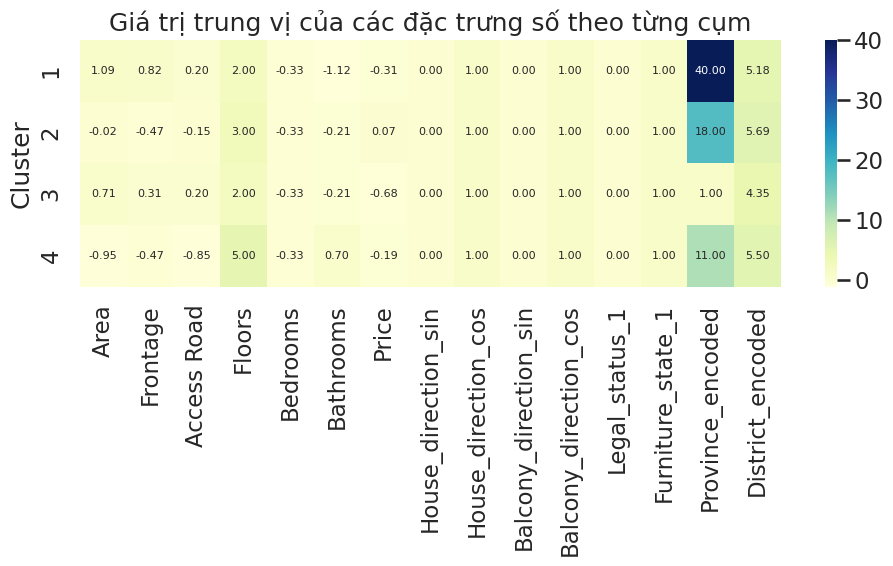

In [244]:
summary = clustered.groupby('Cluster')[numeric_cols].median()

plt.figure(figsize=(10, 6))
sns.heatmap(
    summary,
    cmap='YlGnBu',
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8}   # giảm kích thước chữ (mặc định khoảng 10–12)
)
plt.title("Giá trị trung vị của các đặc trưng số theo từng cụm")
plt.tight_layout()  # giúp bố cục gọn gàng, tránh tràn chữ
plt.show()


**Biểu đồ Silhouette cho từng điểm**

✅ Silhouette Score (k=3): 0.1366


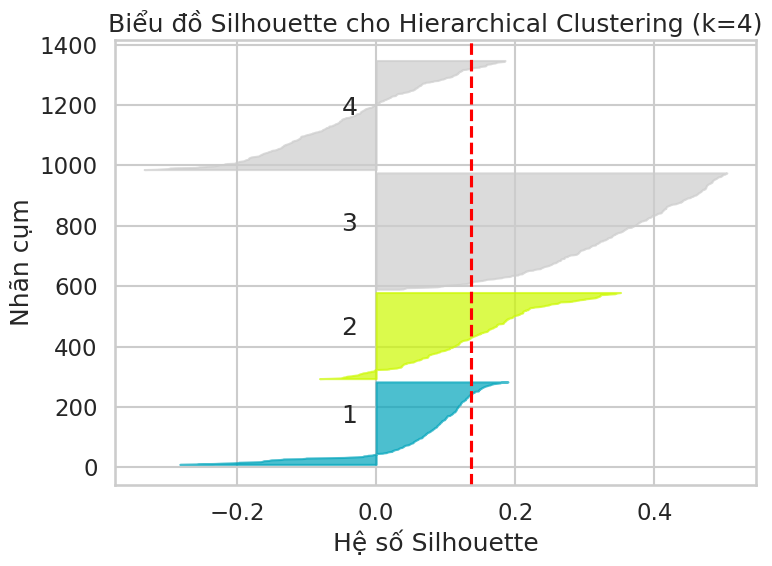

In [245]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
import numpy as np

# Tính hệ số Silhouette cho từng điểm
silhouette_vals = silhouette_samples(X_scaled, labels)
silhouette_avg = silhouette_score(X_scaled, labels)
print(f"✅ Silhouette Score (k=3): {silhouette_avg:.4f}")

# Vẽ biểu đồ silhouette
plt.figure(figsize=(8, 6))
y_lower = 10
for i in range(1, 5):  # vì có 4 cụm
    ith_cluster_silhouette_values = silhouette_vals[labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cm.nipy_spectral(float(i) / 3)
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10  # khoảng cách giữa cụm

plt.axvline(x=silhouette_avg, color="red", linestyle="--")
plt.title("Biểu đồ Silhouette cho Hierarchical Clustering (k=4)")
plt.xlabel("Hệ số Silhouette")
plt.ylabel("Nhãn cụm")
plt.tight_layout()
plt.show()


CLASSIFICATION 

1. Import

In [246]:
# === IMPORT ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay, silhouette_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

2. Tiền xử lý dữ liệu

In [247]:

# Giả sử bạn muốn lấy nhiều cột làm đặc trưng
X_train = vietnam_housing_clean[
    ['Area', 'Access Road', 'Bedrooms', 'Bathrooms', 'Frontage', 'Floors',
     'House_direction_sin', 'House_direction_cos',
     'Balcony_direction_sin', 'Balcony_direction_cos',
     'Legal_status_1', 'Furniture_state_1']
]

X_test = vietnam_housing_test_clean[
    ['Area', 'Access Road', 'Bedrooms', 'Bathrooms', 'Frontage', 'Floors',
     'House_direction_sin', 'House_direction_cos',
     'Balcony_direction_sin', 'Balcony_direction_cos',
     'Legal_status_1', 'Furniture_state_1']
]

In [248]:
# Lấy cột nhãn (target column) riêng biệt
y_train = vietnam_housing_clean['Price']  # Cột nhãn mục tiêu trong dữ liệu huấn luyện
y_test = vietnam_housing_test['Price']

In [249]:
# LẤY y TỪ CÙNG *_clean* VÀ CĂN THEO INDEX CỦA X
y_train_cont = vietnam_housing_clean.loc[X_train.index, 'Price'].copy()
y_test_cont  = vietnam_housing_test_clean.loc[X_test.index,  'Price'].copy()

# (Nếu còn NA) drop đồng bộ theo (X,y)
mask_tr = (~X_train.isna().any(axis=1)) & (~y_train_cont.isna())
mask_te = (~X_test.isna().any(axis=1))  & (~y_test_cont.isna())
X_train, y_train_cont = X_train.loc[mask_tr], y_train_cont.loc[mask_tr]
X_test,  y_test_cont  = X_test.loc[mask_te],  y_test_cont.loc[mask_te]


In [250]:
import numpy as np

thr = float(np.median(y_train_cont))   # hoặc np.mean(...)
y_train_cls = (y_train_cont >= thr).map({False: f"Low(<{thr:.0f})",
                                         True:  f"High(≥{thr:.0f})"}).astype('category')
y_test_cls  = (y_test_cont  >= thr).map({False: f"Low(<{thr:.0f})",
                                         True:  f"High(≥{thr:.0f})"}).astype('category')

print("X_train:", X_train.shape, "| y_train_cls:", y_train_cls.shape)
print("X_test :", X_test.shape,  "| y_test_cls :", y_test_cls.shape)

X_train: (1308, 12) | y_train_cls: (1308,)
X_test : (664, 12) | y_test_cls : (664,)


In [251]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

3. Đánh gía mô hình

In [252]:
def evaluate(model, Xtr, ytr, Xte, yte, title):
    yhat_tr = model.predict(Xtr)
    yhat_te = model.predict(Xte)
    print(f"\n=== {title} ===")
    print(f"Accuracy (train): {accuracy_score(ytr, yhat_tr):.4f}")
    print(f"Accuracy (test) : {accuracy_score(yte, yhat_te):.4f}")
    print(classification_report(yte, yhat_te))

    # Confusion matrix
    cm, labels = confusion_matrix(yte, yhat_te), np.unique(yte)
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest')
    plt.title(f"{title} — Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.yticks(range(len(labels)), labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i,j], ha="center", va="center")
    plt.tight_layout(); plt.show()

    # ROC-AUC nếu nhị phân
    if len(labels) == 2 and hasattr(model, "predict_proba"):
        proba = model.predict_proba(Xte)[:, 1]
        y_true_bin = (yte == labels[1]).astype(int)
        auc = roc_auc_score(y_true_bin, proba)
        print(f"ROC-AUC (test): {auc:.4f}")
        RocCurveDisplay.from_predictions(y_true_bin, proba)
        plt.title(f"{title} — ROC Curve")
        plt.show()

4.GridSearchCV

In [253]:
def run_models(specs, Xtr, ytr, Xte, yte, scoring="accuracy", cv_splits=5):
    rows, out = [], {}
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)

    for name, s in specs.items():
        steps = []
        if s.get("scale", False):
            steps.append(("scaler", StandardScaler()))
        steps.append(("clf", s["est"]))
        pipe = Pipeline(steps)

        gs = GridSearchCV(
            pipe, s["grid"], scoring=scoring,
            cv=cv, n_jobs=-1, refit=True, verbose=0
        )
        gs.fit(Xtr, ytr)

        best = gs.best_estimator_
        out[name] = {"best": best, "params": gs.best_params_}
        rows.append({
            "Model": name,
            "Best Params": gs.best_params_,
            "Test Accuracy": accuracy_score(yte, best.predict(Xte))
        })
        evaluate(best, Xtr, ytr, Xte, yte, name)

    summary = pd.DataFrame(rows).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
    return out, summary

5.Khai báo tham số

In [254]:
model_specs = {
    "Logistic Regression": {
        "est": LogisticRegression(max_iter=2000),
        "scale": True,
        "grid": {
            "clf__C": [0.01, 0.1, 1, 10],
            "clf__penalty": ["l2"],
            "clf__solver": ["lbfgs", "liblinear"]
        }
    },
    "Decision Tree": {
        "est": DecisionTreeClassifier(random_state=42),
        "scale": False,
        "grid": {
            "clf__criterion": ["gini", "entropy"],
            "clf__max_depth": [None, 3, 5, 8, 12],
            "clf__min_samples_split": [2, 5, 10],
            "clf__min_samples_leaf": [1, 2, 5]
        }
    },
    "Random Forest": {
        "est": RandomForestClassifier(random_state=42, n_jobs=-1),
        "scale": False,
        "grid": {
            "clf__n_estimators": [100, 300],
            "clf__max_depth": [None, 8, 12],
            "clf__max_features": ["sqrt", "log2"],
            "clf__min_samples_leaf": [1, 2, 5]
        }
    }
}

6.Chạy huấn luyện


=== Logistic Regression ===
Accuracy (train): 0.7202
Accuracy (test) : 0.7063
              precision    recall  f1-score   support

   High(≥-0)       0.74      0.68      0.71       348
    Low(<-0)       0.68      0.73      0.70       316

    accuracy                           0.71       664
   macro avg       0.71      0.71      0.71       664
weighted avg       0.71      0.71      0.71       664



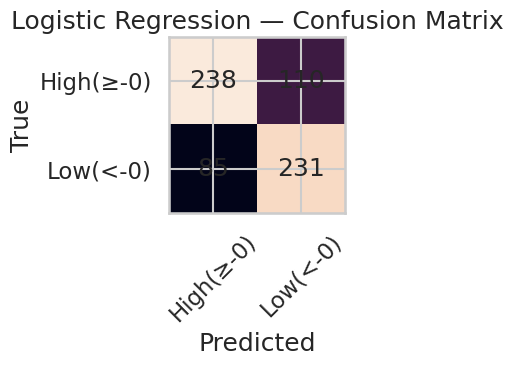

ROC-AUC (test): 0.7760


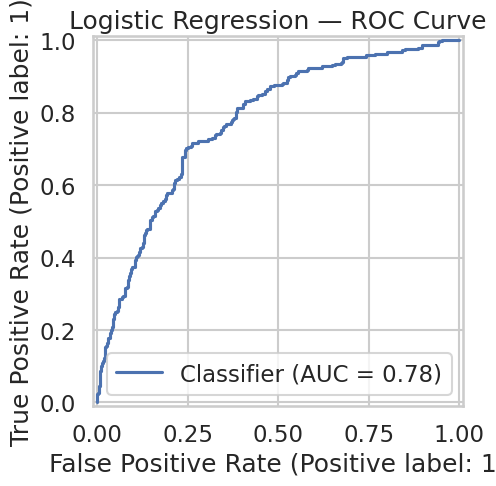


=== Decision Tree ===
Accuracy (train): 0.7309
Accuracy (test) : 0.6928
              precision    recall  f1-score   support

   High(≥-0)       0.80      0.55      0.65       348
    Low(<-0)       0.63      0.84      0.72       316

    accuracy                           0.69       664
   macro avg       0.72      0.70      0.69       664
weighted avg       0.72      0.69      0.69       664



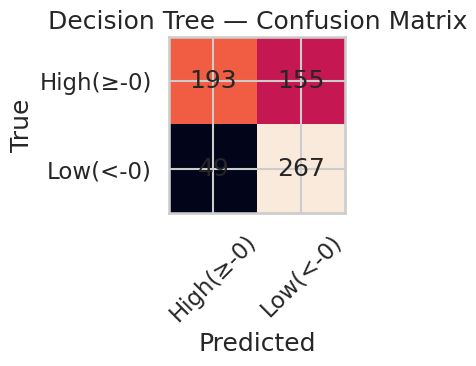

ROC-AUC (test): 0.7213


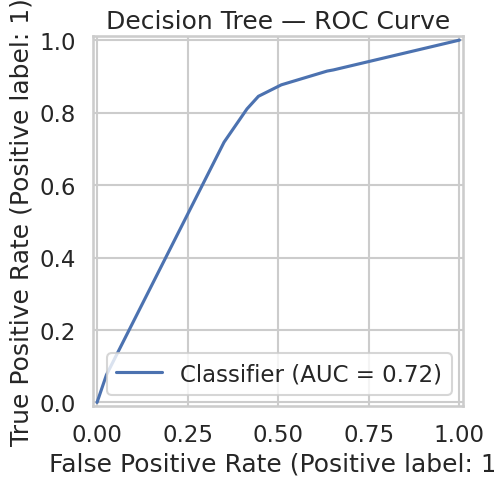


=== Random Forest ===
Accuracy (train): 0.8073
Accuracy (test) : 0.7274
              precision    recall  f1-score   support

   High(≥-0)       0.78      0.67      0.72       348
    Low(<-0)       0.68      0.79      0.73       316

    accuracy                           0.73       664
   macro avg       0.73      0.73      0.73       664
weighted avg       0.73      0.73      0.73       664



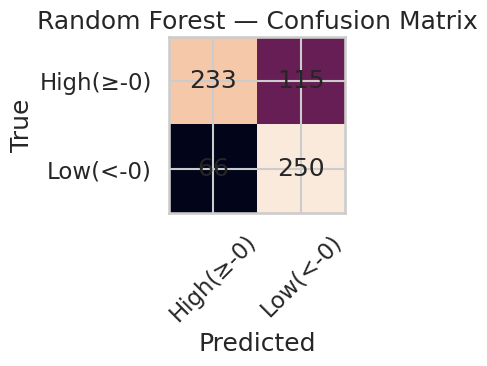

ROC-AUC (test): 0.8044


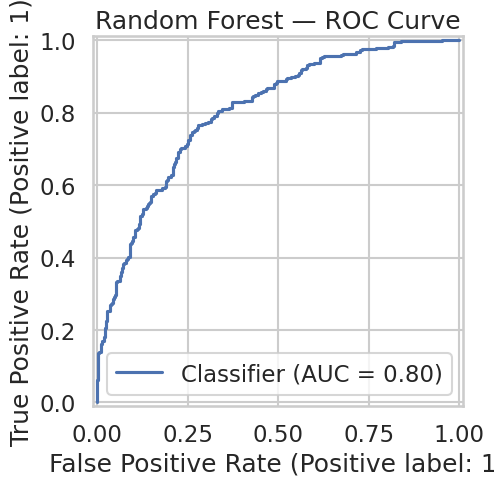

,Model,Best Params,Test Accuracy
0,Random Forest,"{'clf__max_depth': 8, 'clf__max_features': 'sq...",0.727410
1,Logistic Regression,"{'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__so...",0.706325
2,Decision Tree,"{'clf__criterion': 'gini', 'clf__max_depth': 3...",0.692771


In [255]:

out, summary = run_models(
    model_specs,
    X_train, y_train_cls,
    X_test, y_test_cls,
    scoring="accuracy",
    cv_splits=5
)

summary



7.Vẽ biểu đồ so sánh độ chính xác

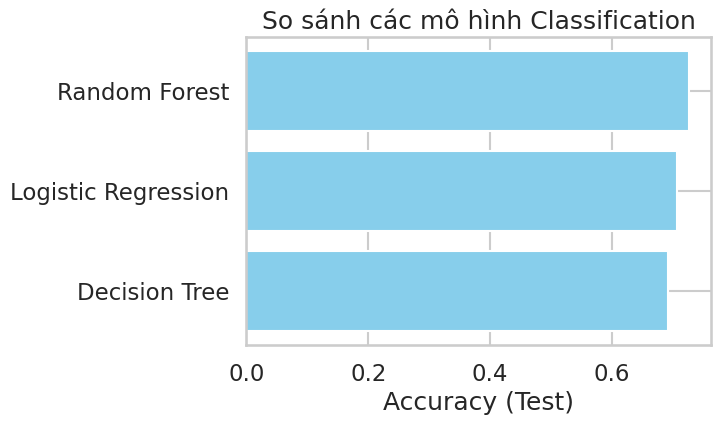

In [256]:
plt.figure(figsize=(6,4))
plt.barh(summary['Model'], summary['Test Accuracy'], color='skyblue')
plt.xlabel('Accuracy (Test)')
plt.title('So sánh các mô hình Classification')
plt.gca().invert_yaxis()
plt.show()

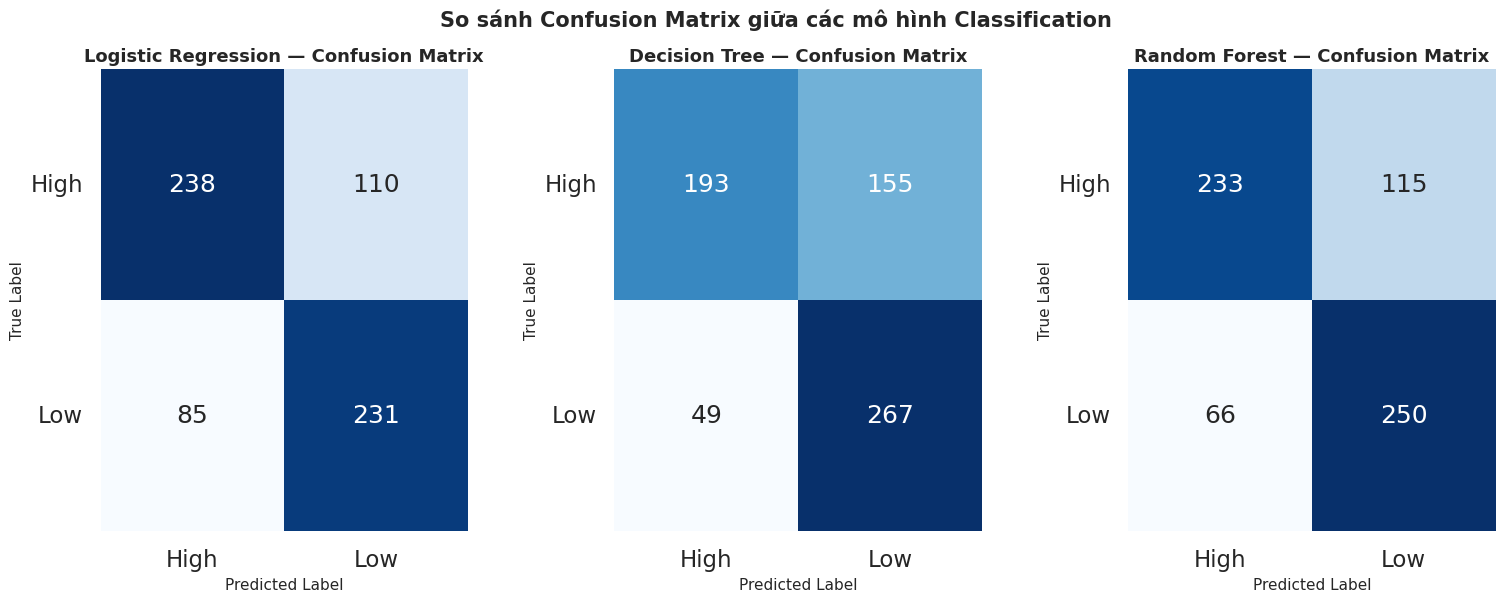

In [257]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# LẤY MÔ HÌNH TỐT NHẤT TỪ GRIDSEARCH
model_lr = out["Logistic Regression"]["best"]
model_dt = out["Decision Tree"]["best"]
model_rf = out["Random Forest"]["best"]

#TẠO NHÃN DỰ ĐOÁN 
y_pred_lr = model_lr.predict(X_test)
y_pred_dt = model_dt.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

# TẠO DANH SÁCH MÔ HÌNH & CONFUSION MATRIX 
model_list = ["Logistic Regression", "Decision Tree", "Random Forest"]
cm_list = [
    confusion_matrix(y_test_cls, y_pred_lr),
    confusion_matrix(y_test_cls, y_pred_dt),
    confusion_matrix(y_test_cls, y_pred_rf)
]

# VẼ BIỂU ĐỒ HEATMAP
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plt.subplots_adjust(wspace=0.4)

for i, (cm, model) in enumerate(zip(cm_list, model_list)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i])
    axes[i].set_title(f"{model} — Confusion Matrix", fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Predicted Label", fontsize=11)
    axes[i].set_ylabel("True Label", fontsize=11)
    axes[i].set_xticklabels(['High', 'Low'])
    axes[i].set_yticklabels(['High', 'Low'], rotation=0)

plt.suptitle("So sánh Confusion Matrix giữa các mô hình Classification", fontsize=15, fontweight='bold')
plt.show()


In [258]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score

model_lr = out["Logistic Regression"]["best"]
model_dt = out["Decision Tree"]["best"]
model_rf = out["Random Forest"]["best"]

y_pred_lr = model_lr.predict(X_test)
y_pred_dt = model_dt.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

model_list = ["Logistic Regression", "Decision Tree", "Random Forest"]

acc_list = [
    accuracy_score(y_test_cls, y_pred_lr),
    accuracy_score(y_test_cls, y_pred_dt),
    accuracy_score(y_test_cls, y_pred_rf)
]

auc_list = [
    roc_auc_score(y_test_cls, y_prob_lr),
    roc_auc_score(y_test_cls, y_prob_dt),
    roc_auc_score(y_test_cls, y_prob_rf)
]

result_df = pd.DataFrame({
    "Model": model_list,
    "Accuracy": acc_list,
    "ROC-AUC": auc_list
}).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

print("Bảng tổng hợp các chỉ số đánh giá mô hình Classification:")
display(result_df.style.background_gradient(cmap='Blues', subset=['Accuracy', 'ROC-AUC']))


Bảng tổng hợp các chỉ số đánh giá mô hình Classification:


,Model,Accuracy,ROC-AUC
0,Random Forest,0.727410,0.804416
1,Logistic Regression,0.706325,0.776044
2,Decision Tree,0.692771,0.721255


## VISUALIZATION FOR LOGISTIC REGRESSION

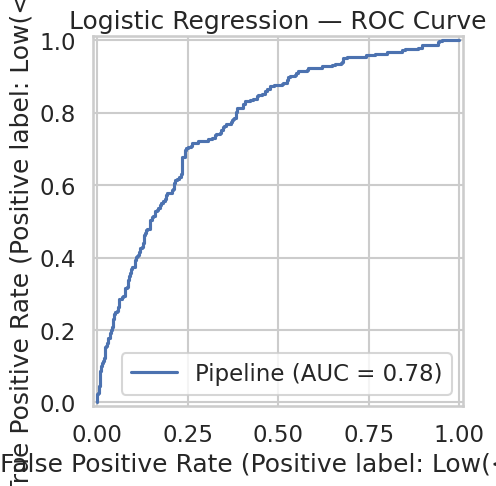

In [259]:
from sklearn.metrics import RocCurveDisplay

# Vẽ ROC Curve
RocCurveDisplay.from_estimator(
    out["Logistic Regression"]["best"], X_test, y_test_cls
)
plt.title("Logistic Regression — ROC Curve")
plt.show()


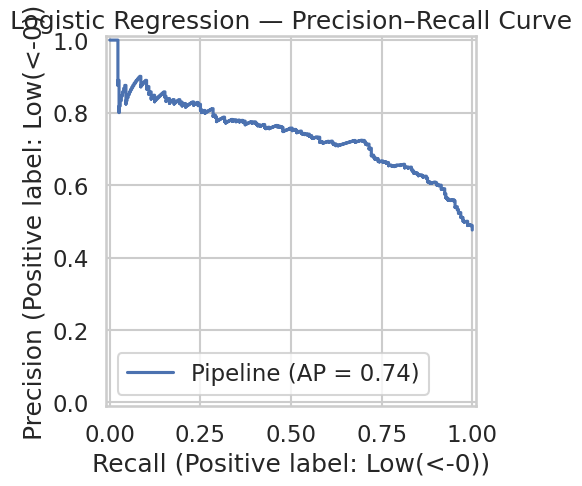

In [260]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    out["Logistic Regression"]["best"], X_test, y_test_cls
)
plt.title("Logistic Regression — Precision–Recall Curve")
plt.show()


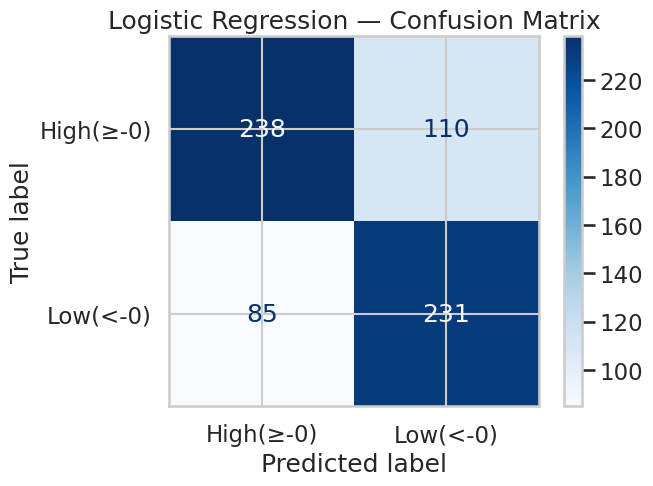

In [261]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred = out["Logistic Regression"]["best"].predict(X_test)
cm = confusion_matrix(y_test_cls, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test_cls))
disp.plot(cmap="Blues", values_format='d')
plt.title("Logistic Regression — Confusion Matrix")
plt.show()


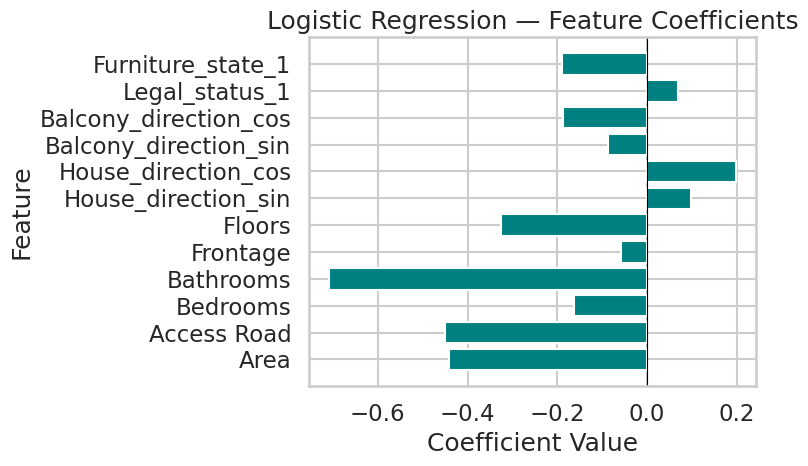

In [262]:
best_lr = out["Logistic Regression"]["best"].named_steps["clf"]
coefs = best_lr.coef_[0]
features = X_train.columns

plt.figure(figsize=(8,5))
plt.barh(features, coefs, color="teal")
plt.title("Logistic Regression — Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


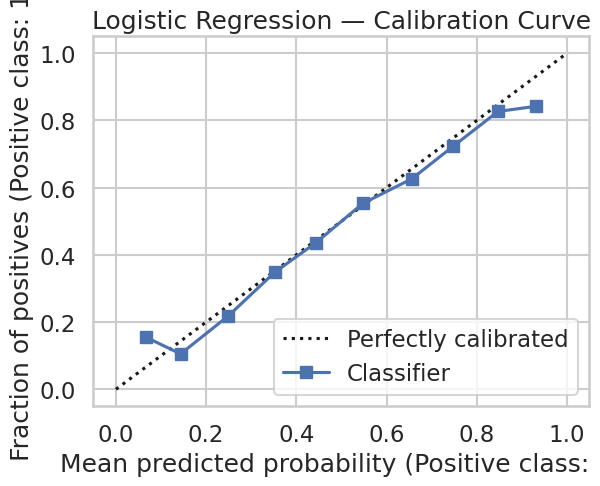

In [263]:
from sklearn.calibration import CalibrationDisplay

y_proba = out["Logistic Regression"]["best"].predict_proba(X_test)[:, 1]
CalibrationDisplay.from_predictions(
    (y_test_cls == y_test_cls.cat.categories[1]).astype(int),
    y_proba,
    n_bins=10
)
plt.title("Logistic Regression — Calibration Curve")
plt.show()


## VISUALIZATION FOR DECISION TREE

In [264]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score
)
from sklearn.tree import plot_tree

# Lấy mô hình Decision Tree tốt nhất từ dict out
tree_model = out["Decision Tree"]["best"]
clf_tree = tree_model.named_steps["clf"]
title = "Decision Tree"


**Confusion Matrix**

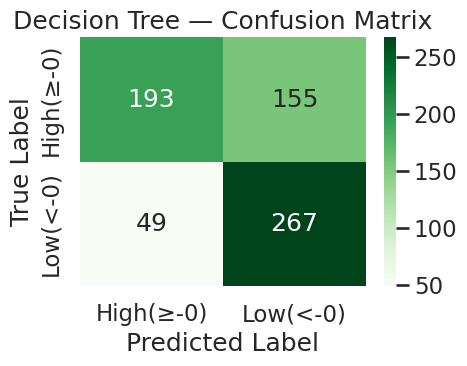

In [265]:
def plot_confusion_matrix_heatmap(model, Xte, yte, title):
    y_pred = model.predict(Xte)
    cm = confusion_matrix(yte, y_pred)
    labels = np.unique(yte)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=labels, yticklabels=labels)
    plt.title(f"{title} — Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix_heatmap(tree_model, X_test, y_test_cls, title)


**ROC Curve/Precision-Recall**


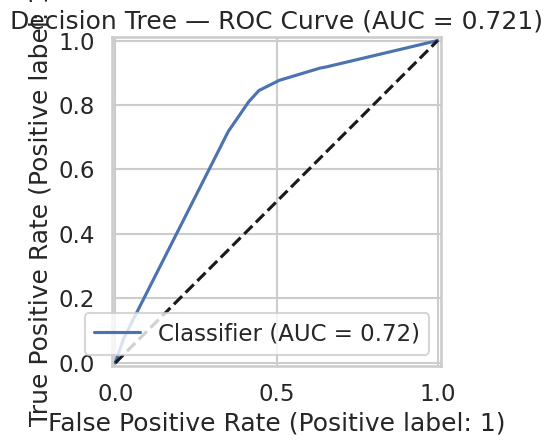

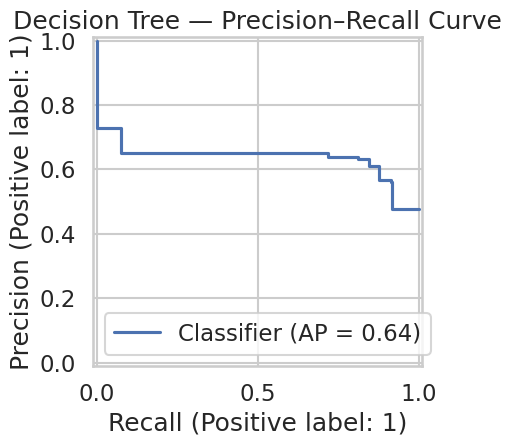

In [266]:
def plot_roc_pr_curves(model, Xte, yte, title):
    y_proba = model.predict_proba(Xte)[:, 1]
    y_true_bin = (yte == yte.cat.categories[1]).astype(int)
    auc = roc_auc_score(y_true_bin, y_proba)

    # ROC Curve
    RocCurveDisplay.from_predictions(y_true_bin, y_proba)
    plt.title(f"{title} — ROC Curve (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.tight_layout()
    plt.show()

    # Precision–Recall Curve
    PrecisionRecallDisplay.from_predictions(y_true_bin, y_proba)
    plt.title(f"{title} — Precision–Recall Curve")
    plt.tight_layout()
    plt.show()

plot_roc_pr_curves(tree_model, X_test, y_test_cls, title)


**Tree Structure**

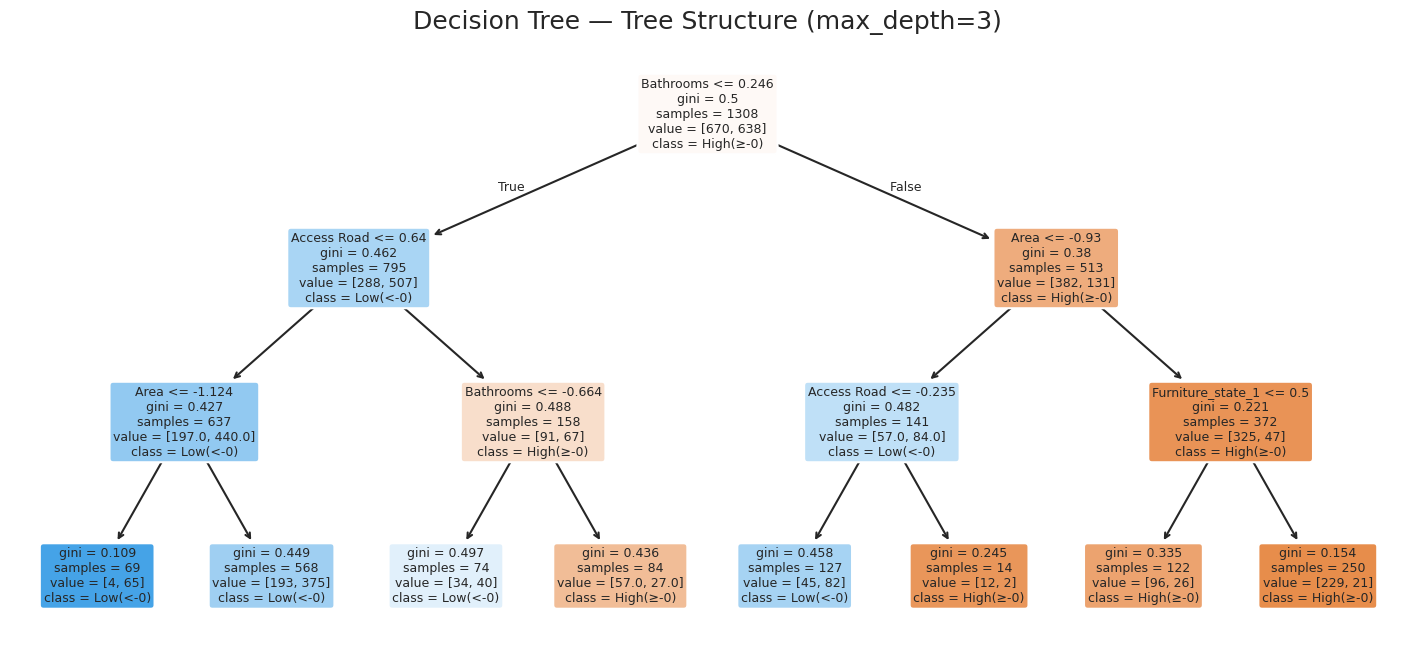

In [267]:
def plot_decision_tree_structure(model, feature_names, title, max_depth=3):
    plt.figure(figsize=(18, 8))
    plot_tree(
        model,
        feature_names=feature_names,
        class_names=[str(c) for c in model.classes_],
        filled=True, rounded=True,
        fontsize=9, max_depth=max_depth
    )
    plt.title(f"{title} — Tree Structure (max_depth={max_depth})")
    plt.show()

plot_decision_tree_structure(clf_tree, X_train.columns, title, max_depth=3)


## VISUALIZATION FOR RANDOM FOREST

**Confusion Matrix**

Note: you may need to restart the kernel to use updated packages.


<Figure size 400x400 with 0 Axes>

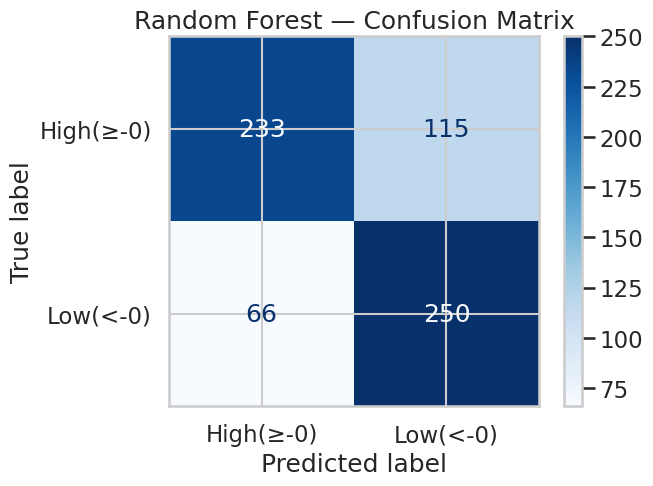

In [268]:
#  Bộ biểu đồ đánh giá mô hình Random Forest
%pip install shap -q
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.inspection import PartialDependenceDisplay
import shap
import numpy as np

rf_model = out["Random Forest"]["best"]

# Confusion Matrix 
plt.figure(figsize=(4, 4))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test_cls, cmap="Blues", values_format="d")
plt.title("Random Forest — Confusion Matrix")
plt.show()

**ROC Curve/Precision–Recall Curve**

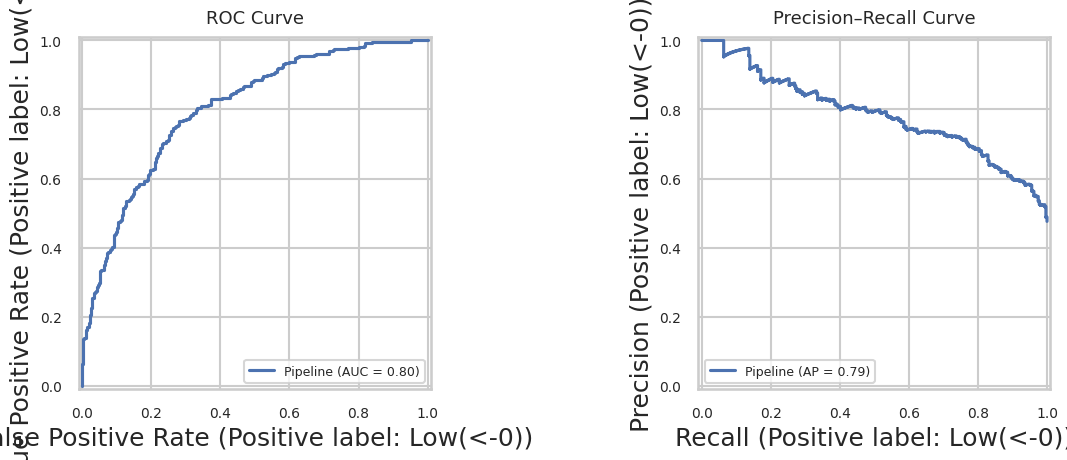

In [269]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,5), dpi=100)

RocCurveDisplay.from_estimator(rf_model, X_test, y_test_cls, ax=axes[0])
axes[0].set_title("ROC Curve", fontsize=13, pad=10)
axes[0].tick_params(labelsize=10)
axes[0].legend(loc='lower right', fontsize=9)

PrecisionRecallDisplay.from_estimator(rf_model, X_test, y_test_cls, ax=axes[1])
axes[1].set_title("Precision–Recall Curve", fontsize=13, pad=10)
axes[1].tick_params(labelsize=10)
axes[1].legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, top=0.88)  
plt.show()


**Feature Importance**

/tmp/ipykernel_5343/749850736.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[v for _, v in feat_imp[:10]], y=[f for f, _ in feat_imp[:10]], palette="crest")


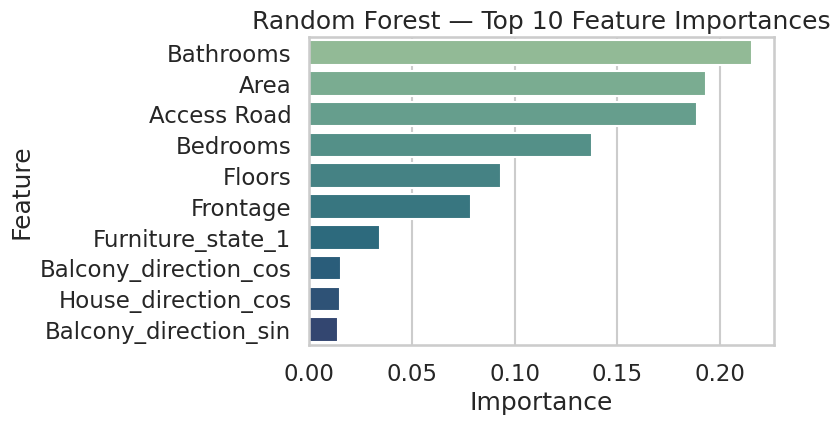

In [270]:
importances = rf_model.named_steps['clf'].feature_importances_

feat_imp = sorted(zip(X_test.columns, importances), key=lambda x: x[1], reverse=True)
plt.figure(figsize=(6, 4))
sns.barplot(x=[v for _, v in feat_imp[:10]], y=[f for f, _ in feat_imp[:10]], palette="crest")
plt.title("Random Forest — Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

**Prediction Probability Histogram**

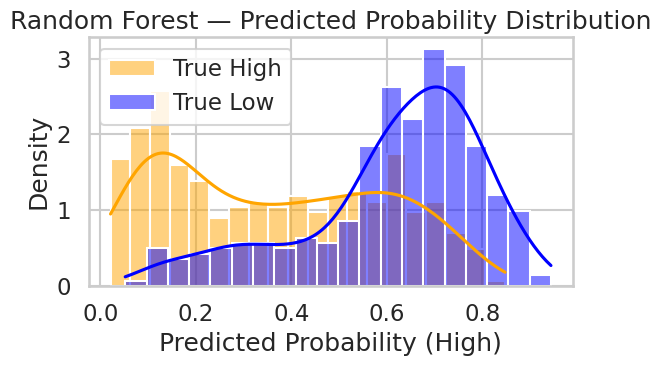

In [271]:
import matplotlib.pyplot as plt
import seaborn as sns

proba = rf_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(6, 4))
sns.histplot(
    proba[y_test_cls == "High(≥-0)"],
    color="orange", label="True High",
    kde=True, stat="density", bins=20, alpha=0.5, multiple="layer"
)
sns.histplot(
    proba[y_test_cls == "Low(<-0)"],
    color="blue", label="True Low",
    kde=True, stat="density", bins=20, alpha=0.5, multiple="layer"
)
plt.legend()
plt.title("Random Forest — Predicted Probability Distribution")
plt.xlabel("Predicted Probability (High)")
plt.tight_layout()
plt.show()
plt.close()


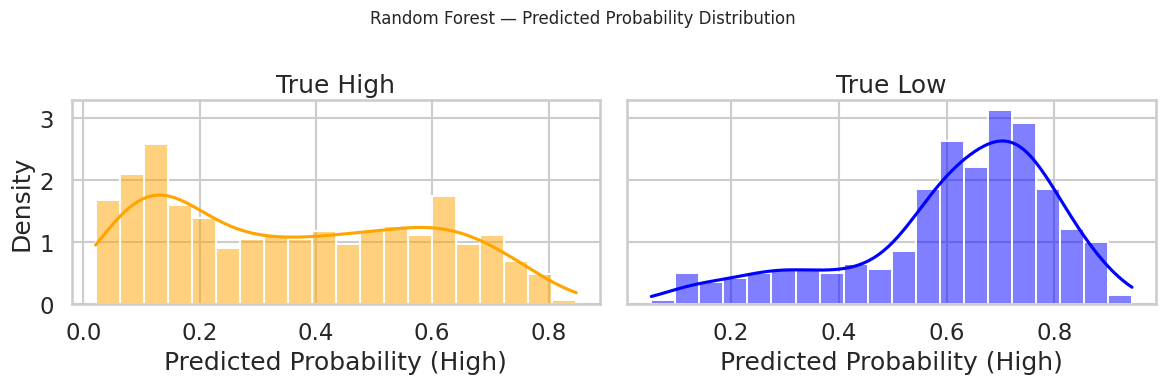

In [272]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.histplot(proba[y_test_cls == "High(≥-0)"], color="orange", kde=True, stat="density", bins=20, ax=axes[0])
axes[0].set_title("True High")
axes[0].set_xlabel("Predicted Probability (High)")

sns.histplot(proba[y_test_cls == "Low(<-0)"], color="blue", kde=True, stat="density", bins=20, ax=axes[1])
axes[1].set_title("True Low")
axes[1].set_xlabel("Predicted Probability (High)")

fig.suptitle("Random Forest — Predicted Probability Distribution", fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# Dự báo giá nhà

In [273]:
rf_best   = out['Random Forest']['best']
tree_best = out['Decision Tree']['best']
log_best  = out['Logistic Regression']['best']

In [274]:
# ===== DỰ BÁO =====
best = rf_best  

# Dự báo nhãn (High/Low) và xác suất thuộc nhóm High
y_pred_label = best.predict(X_test)
y_pred_prob  = best.predict_proba(X_test)[:, 1]

# Gộp kết quả vào bảng test
pred_table = vietnam_housing_test_clean.copy()
pred_table['Pred_Prob_High'] = y_pred_prob
pred_table['Pred_Label'] = y_pred_label

# ===== TÍNH THEO MEDIAN PRICE =====
import numpy as np

thr = float(np.median(y_train_cont))  # median của cột Price trong tập train
print(f"Median của Price (ngưỡng phân loại): {thr:.2f} ")

# Đếm số căn dự báo High / Low
n_high = (pred_table['Pred_Label'].astype(str).str.contains("High")).sum()
n_low  = (pred_table['Pred_Label'].astype(str).str.contains("Low")).sum()
total  = len(pred_table)

print(f"Dự báo: {n_high}/{total} căn có giá ≥ {thr:.2f} ; {n_low}/{total} căn có giá < {thr:.2f} ")

# Xem vài dòng đầu tiên
pred_table.head()


Median của Price (ngưỡng phân loại): -0.16 
Dự báo: 299/664 căn có giá ≥ -0.16 ; 365/664 căn có giá < -0.16 


,Province,District,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,...,House_direction_sin,House_direction_cos,Balcony_direction_sin,Balcony_direction_cos,Legal_status_1,Furniture_state_1,Province_encoded,District_encoded,Pred_Prob_High,Pred_Label
1616,Đà Nẵng,Ngũ Hành Sơn,1.531071,0.809377,-0.231670,Tây - Nam,Tây - Nam,2,-0.442300,-0.226673,...,0.0,1.0,0.0,1.0,0,1,38,5.905480,0.577877,Low(<-0)
254,Khánh Hòa,Nha Trang,1.452798,0.809377,1.219409,Đông - Bắc,Đông - Bắc,2,-0.442300,-1.138858,...,0.0,1.0,0.0,1.0,0,0,20,5.469248,0.572599,Low(<-0)
1146,Hồ Chí Minh,Gò Vấp,-1.482431,-0.955616,-0.521886,Tây - Bắc,Tây - Bắc,2,-1.681488,-2.051043,...,0.0,1.0,0.0,1.0,0,1,18,6.068340,0.891076,Low(<-0)
188,Hà Nội,Hà Đông,-1.130204,-1.291805,-0.812101,Đông - Nam,Đông - Nam,5,-0.442300,0.685513,...,0.0,1.0,0.0,1.0,0,0,12,5.617487,0.751871,Low(<-0)
1808,Hà Nội,Cầu Giấy,-0.308339,-0.591411,-0.666993,Tây - Nam,Tây - Nam,3,0.796887,-0.226673,...,0.0,1.0,0.0,1.0,0,0,12,6.036519,0.701410,Low(<-0)
